# External-Sampling And Deep CFR Diagnostics

This notebook separates sampling error, advantage-network error, and average-strategy-network error.

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from liars_poker.core import GameSpec
from liars_poker.policies.tabular_dense import DenseTabularPolicy, mix_dense_multiple
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.training.cfr_external_sampling_dense import external_sampling_cfr_loop
from liars_poker.training.deep_cfr import deep_cfr_loop, deep_cfr_timed_loop, save_deep_cfr_run

In [3]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=2,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)
spec.to_short_str()

'r4_s4_h2_hpt_ss'

## Verify incremental exact averaging

The incremental averager must exactly match the already-tested posterior-aware `mix_dense_multiple` implementation.

In [4]:
rng = np.random.default_rng(4)
snapshots = [DenseTabularPolicy(spec), DenseTabularPolicy(spec)]
for policy in snapshots:
    for hid in range(policy.S.shape[0]):
        cols = np.flatnonzero(policy.legal_mask[hid])
        rows = rng.random((policy.S.shape[1], len(cols)))
        rows /= rows.sum(axis=1, keepdims=True)
        policy.S[hid].fill(0.0)
        policy.S[hid, :, cols] = rows.T
    policy.recompute_likelihoods()

weights = np.array([1.0, 3.0])
expected = mix_dense_multiple(snapshots, weights / weights.sum())
averager_check = ExactDenseStrategyAverager(spec)
for policy, weight in zip(snapshots, weights):
    averager_check.observe(policy, weight=weight)
actual = averager_check.average_policy()

max_abs_diff = float(np.max(np.abs(expected.S - actual.S)))
assert max_abs_diff < 1e-6
max_abs_diff

1.2293457984924316e-07

## Compare tabular external sampling with Deep CFR

Both methods use external-sampling traversals. The tabular baseline removes neural approximation; the Deep CFR run additionally tracks its exact dense average and held-out fit diagnostics.

In [45]:
iterations = 200
traversals_per_player = 50
eval_every = 5

external_policy, external_logs, external_cfr = external_sampling_cfr_loop(
    spec,
    iterations=iterations,
    traversals_per_player=traversals_per_player,
    eval_every=eval_every,
    cfr_kwargs={'seed': 7, 'strategy_weighting': 'linear'},
    debug=True,
)

# exact_averager = ExactDenseStrategyAverager(spec)
# deep_policy, deep_logs, deep_trainer = deep_cfr_loop(
#     spec,
#     iterations=iterations,
#     traversals_per_player=traversals_per_player,
#     eval_every=eval_every,
#     exact_averager=exact_averager,
#     trainer_kwargs={
#         'hidden_sizes': (64, 64),
#         'advantage_buffer_capacity': 50_000,
#         'strategy_buffer_capacity': 50_000,
#         'advantage_train_steps': 100,
#         'strategy_train_steps': 100,
#         'batch_size': 128,
#         'learning_rate': 1e-3,
#         'strategy_weighting': 'linear',
#         'validation_fraction': 0.05,
#         'validation_buffer_capacity': 10_000,
#         'seed': 7,
#     },
#     debug=True,
# )

[external-cfr] iter=1 elapsed=0.18s traverse=0.18s
[external-cfr] iter=2 elapsed=0.40s traverse=0.22s
[external-cfr] iter=3 elapsed=0.61s traverse=0.21s
[external-cfr] iter=4 elapsed=0.82s traverse=0.22s
[external-cfr] iter=5 elapsed=1.01s traverse=0.19s
[external-cfr] iter=6 elapsed=3.91s traverse=0.22s
[external-cfr] iter=7 elapsed=4.11s traverse=0.20s
[external-cfr] iter=8 elapsed=4.33s traverse=0.22s
[external-cfr] iter=9 elapsed=4.54s traverse=0.21s
[external-cfr] iter=10 elapsed=4.77s traverse=0.23s
[external-cfr] iter=11 elapsed=7.65s traverse=0.21s
[external-cfr] iter=12 elapsed=7.86s traverse=0.21s
[external-cfr] iter=13 elapsed=8.06s traverse=0.20s
[external-cfr] iter=14 elapsed=8.28s traverse=0.21s
[external-cfr] iter=15 elapsed=8.48s traverse=0.20s
[external-cfr] iter=16 elapsed=11.33s traverse=0.22s
[external-cfr] iter=17 elapsed=11.54s traverse=0.21s
[external-cfr] iter=18 elapsed=11.76s traverse=0.22s
[external-cfr] iter=19 elapsed=11.97s traverse=0.21s
[external-cfr] it

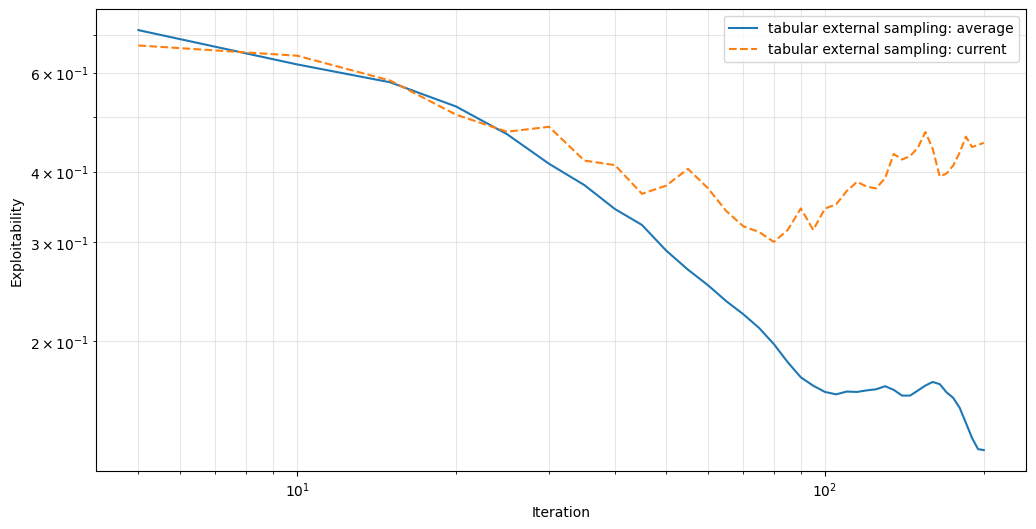

In [47]:
def transformed(series, key):
    return [max(2 * point[key] - 1, 1e-8) for point in series]

fig, ax = plt.subplots(figsize=(12, 6))
external_series = external_logs['exploitability_series']
# deep_series = deep_logs['exploitability_series']
ax.plot([p['iter'] for p in external_series], transformed(external_series, 'predicted_avg'), label='tabular external sampling: average')
ax.plot([p['iter'] for p in external_series], transformed(external_series, 'current_predicted_avg'), '--', label='tabular external sampling: current')
# ax.plot([p['iter'] for p in deep_series], transformed(deep_series, 'predicted_avg'), label='Deep CFR: learned average')
# ax.plot([p['iter'] for p in deep_series], transformed(deep_series, 'exact_average_predicted_avg'), label='Deep CFR: exact average')
# ax.plot([p['iter'] for p in deep_series], transformed(deep_series, 'current_predicted_avg'), '--', label='Deep CFR: current')
ax.set(xscale='log', yscale='log', xlabel='Iteration', ylabel='Exploitability')
ax.grid(True, which='both', alpha=0.3)
ax.legend();

In [49]:
external_series

[{'iter': 5,
  'p_first': 0.9179106143506047,
  'p_second': 0.7956511330644251,
  'predicted_avg': 0.8567808737075149,
  'current_p_first': 0.9099109412051088,
  'current_p_second': 0.7602894502441819,
  'current_predicted_avg': 0.8351001957246453},
 {'iter': 10,
  'p_first': 0.8835279148227484,
  'p_second': 0.7366257046086789,
  'predicted_avg': 0.8100768097157136,
  'current_p_first': 0.8656797337223965,
  'current_p_second': 0.7769831951569109,
  'current_predicted_avg': 0.8213314644396537},
 {'iter': 15,
  'p_first': 0.8487116911186008,
  'p_second': 0.7277673207965023,
  'predicted_avg': 0.7882395059575515,
  'current_p_first': 0.8299138748415043,
  'current_p_second': 0.7507483918786569,
  'current_predicted_avg': 0.7903311333600807},
 {'iter': 20,
  'p_first': 0.8128196730828395,
  'p_second': 0.709298357623365,
  'predicted_avg': 0.7610590153531023,
  'current_p_first': 0.7923285287172116,
  'current_p_second': 0.7125900277550838,
  'current_predicted_avg': 0.7524592782361477}

In [50]:
# def mean_validation_metric(record, family, key):
#     values = [player.get(key, np.nan) for player in record['validation'][family]]
#     return float(np.nanmean(values))

# training = [record for record in deep_logs['training_series'] if 'validation' in record]
# x = [record['iteration'] for record in training]
# fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
# plots = [
#     ('advantage', 'mse', 'Advantage held-out MSE'),
#     ('advantage', 'sign_accuracy', 'Advantage sign accuracy'),
#     ('advantage', 'strategy_tv', 'Regret-matched strategy TV'),
#     ('strategy', 'strategy_tv', 'Average-network strategy TV'),
# ]
# for ax, (family, key, title) in zip(axes.flat, plots):
#     ax.plot(x, [mean_validation_metric(record, family, key) for record in training])
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)
# for ax in axes[-1]:
#     ax.set_xlabel('Iteration')
# fig.tight_layout();

In [51]:
# import pandas as pd

# def exploitability_summary_row(method, strategy, series, key):
#     values = np.asarray([2 * point[key] - 1 for point in series])
#     best_idx = int(np.argmin(values))
#     return {
#         'method': method,
#         'strategy': strategy,
#         'final exploitability': values[-1],
#         'best exploitability': values[best_idx],
#         'best iteration': series[best_idx]['iter'],
#         'final / best': values[-1] / max(values[best_idx], 1e-12),
#         'evaluations': len(series),
#     }

# exploitability_summary = pd.DataFrame([
#     exploitability_summary_row('Tabular external sampling', 'average', external_series, 'predicted_avg'),
#     exploitability_summary_row('Tabular external sampling', 'current', external_series, 'current_predicted_avg'),
#     exploitability_summary_row('Deep CFR', 'learned average', deep_series, 'predicted_avg'),
#     exploitability_summary_row('Deep CFR', 'exact average', deep_series, 'exact_average_predicted_avg'),
#     exploitability_summary_row('Deep CFR', 'current', deep_series, 'current_predicted_avg'),
# ]).set_index(['method', 'strategy'])

# exploitability_summary.style.format({
#     'final exploitability': '{:.6f}',
#     'best exploitability': '{:.6f}',
#     'final / best': '{:.2f}x',
# }).background_gradient(subset=['final exploitability', 'best exploitability'], cmap='RdYlGn_r')

## Offline teacher experiment

This isolates neural approximation from online Deep CFR. We freeze the trained tabular external-sampling CFR regrets, fit fresh advantage networks to every infoset, compile their regret-matched current strategy, and compare it with the tabular teacher using exact exploitability.

Targets are normalized independently at each infoset. This removes arbitrary cumulative-regret scale while preserving signs, relative positive regrets, and therefore the teacher's regret-matched strategy.

In [7]:
import torch
import pandas as pd

from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.policies.neural import InfosetEncoder, NeuralMLP

teacher_encoder = InfosetEncoder(spec)

def hid_to_history(hid, k):
    return tuple(action for action in range(k) if hid & (1 << action))

def build_teacher_dataset(pid):
    regrets = external_cfr.R0 if pid == 0 else external_cfr.R1
    features, targets, masks = [], [], []

    for hid in range(external_cfr.H):
        if (hid.bit_count() & 1) != pid:
            continue

        history = hid_to_history(hid, external_cfr.k)
        x = teacher_encoder.encode_hands(external_cfr.hands, history)
        y = regrets[hid].astype(np.float32, copy=True)
        mask = np.broadcast_to(external_cfr.legal_mask[hid], y.shape).copy()
        y[~mask] = 0.0

        scale = np.max(np.abs(y), axis=1, keepdims=True)
        y = np.divide(y, scale, out=np.zeros_like(y), where=scale > 0.0)

        features.append(x)
        targets.append(y)
        masks.append(mask)

    x = np.concatenate(features)
    y = np.concatenate(targets)
    mask = np.concatenate(masks)
    return {'x': x, 'y': y, 'mask': mask, 'active': np.any(y != 0.0, axis=1)}

teacher_datasets = [build_teacher_dataset(pid) for pid in (0, 1)]
pd.DataFrame([
    {
        'player': pid + 1,
        'rows': len(data['x']),
        'active regret rows': int(data['active'].sum()),
        'active fraction': float(data['active'].mean()),
    }
    for pid, data in enumerate(teacher_datasets)
])

NameError: name 'external_cfr' is not defined

In [54]:
def regret_matched_strategy(regrets, mask):
    positive = np.maximum(regrets, 0.0) * mask
    totals = positive.sum(axis=1, keepdims=True)
    strategy = np.divide(positive, totals, out=np.zeros_like(positive), where=totals > 0.0)
    fallback = totals[:, 0] <= 0.0
    strategy[fallback] = mask[fallback] / mask[fallback].sum(axis=1, keepdims=True)
    return strategy

def fit_offline_advantage_model(
    data,
    *,
    hidden_sizes=(256, 256),
    epochs=300,
    batch_size=256,
    learning_rate=1e-3,
    train_fraction=1.0,
    snapshot_every=50,
    eval_every=10,
    seed=0,
):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(data['x']))
    split = min(len(order), max(1, int(train_fraction * len(order))))
    train_idx = torch.as_tensor(order[:split], dtype=torch.long)
    val_idx = torch.as_tensor(order[split:], dtype=torch.long)
    eval_idx = val_idx if len(val_idx) else train_idx

    x = torch.as_tensor(data['x'], dtype=torch.float32)
    y = torch.as_tensor(data['y'], dtype=torch.float32)
    mask = torch.as_tensor(data['mask'], dtype=torch.float32)
    model = NeuralMLP(teacher_encoder.input_dim, teacher_encoder.action_dim, hidden_sizes)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []
    snapshots = {}

    for epoch in range(1, epochs + 1):
        model.train()
        shuffled = train_idx[torch.randperm(len(train_idx))]
        for start in range(0, len(shuffled), batch_size):
            idx = shuffled[start:start + batch_size]
            prediction = model(x[idx])
            loss = (((prediction - y[idx]) ** 2) * mask[idx]).sum() / mask[idx].sum()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch == 1 or epoch % snapshot_every == 0 or epoch == epochs:
            snapshots[epoch] = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

        if epoch == 1 or epoch % eval_every == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                prediction = model(x[eval_idx]).numpy()
            eval_order = order[split:] if len(val_idx) else order[:split]
            target = data['y'][eval_order]
            legal = data['mask'][eval_order]
            mse = float((((prediction - target) ** 2) * legal).sum() / legal.sum())
            sign_accuracy = float((np.sign(prediction[legal]) == np.sign(target[legal])).mean())
            predicted_strategy = regret_matched_strategy(prediction, legal)
            target_strategy = regret_matched_strategy(target, legal)
            strategy_tv = float(0.5 * np.abs(predicted_strategy - target_strategy).sum(axis=1).mean())
            history.append({'epoch': epoch, 'mse': mse, 'sign_accuracy': sign_accuracy, 'strategy_tv': strategy_tv})

    return model, history, snapshots

offline_fit_config = {
    'hidden_sizes': (64, 64),
    'epochs': 1000,
    'batch_size': 256,
    'learning_rate': 1e-3,
    'train_fraction': 1.0,
    'snapshot_every': 50,
    'eval_every': 10
}
offline_models, offline_histories, offline_snapshots = [], [], []
for pid, data in enumerate(teacher_datasets):
    model, history, snapshots = fit_offline_advantage_model(data, seed=100 + pid, **offline_fit_config)
    offline_models.append(model)
    offline_histories.append(history)
    offline_snapshots.append(snapshots)
    print(f'player {pid + 1}: final evaluation metrics = {history[-1]}')

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [9]:
def compile_offline_current_policy(models):
    policy = DenseTabularPolicy(spec)
    for hid in range(policy.S.shape[0]):
        pid = policy.pid_to_act(hid)
        history = hid_to_history(hid, policy.k)
        x = torch.as_tensor(teacher_encoder.encode_hands(policy.hands, history), dtype=torch.float32)
        models[pid].eval()
        with torch.no_grad():
            regrets = models[pid](x).numpy()
        mask = np.broadcast_to(policy.legal_mask[hid], regrets.shape)
        policy.S[hid] = regret_matched_strategy(regrets, mask)
    policy.recompute_likelihoods()
    return policy

def exact_exploitability(policy):
    _, meta = best_response_dense(spec, policy, debug=False, store_state_values=False)
    p_first, p_second = meta['computer'].exploitability()
    return p_first + p_second - 1.0

teacher_current_policy = external_cfr.current_policy()
teacher_current_exploitability = exact_exploitability(teacher_current_policy)

snapshot_epochs = sorted(set(offline_snapshots[0]) & set(offline_snapshots[1]))
offline_exact_history = []
for epoch in snapshot_epochs:
    snapshot_models = []
    for pid in (0, 1):
        model = NeuralMLP(
            teacher_encoder.input_dim,
            teacher_encoder.action_dim,
            offline_fit_config['hidden_sizes'],
        )
        model.load_state_dict(offline_snapshots[pid][epoch])
        snapshot_models.append(model)
    snapshot_policy = compile_offline_current_policy(snapshot_models)
    offline_exact_history.append({'epoch': epoch, 'exploitability': exact_exploitability(snapshot_policy)})
    print(f'epoch {epoch}: exact exploitability = {offline_exact_history[-1]["exploitability"]:.6f}')

offline_current_policy = compile_offline_current_policy(offline_models)
offline_current_exploitability = exact_exploitability(offline_current_policy)

offline_comparison = pd.DataFrame([
    {'policy': 'tabular teacher current', 'exact exploitability': teacher_current_exploitability},
    {'policy': 'offline neural current', 'exact exploitability': offline_current_exploitability},
]).set_index('policy')
offline_comparison.style.format({'exact exploitability': '{:.6f}'})

NameError: name 'external_cfr' is not defined

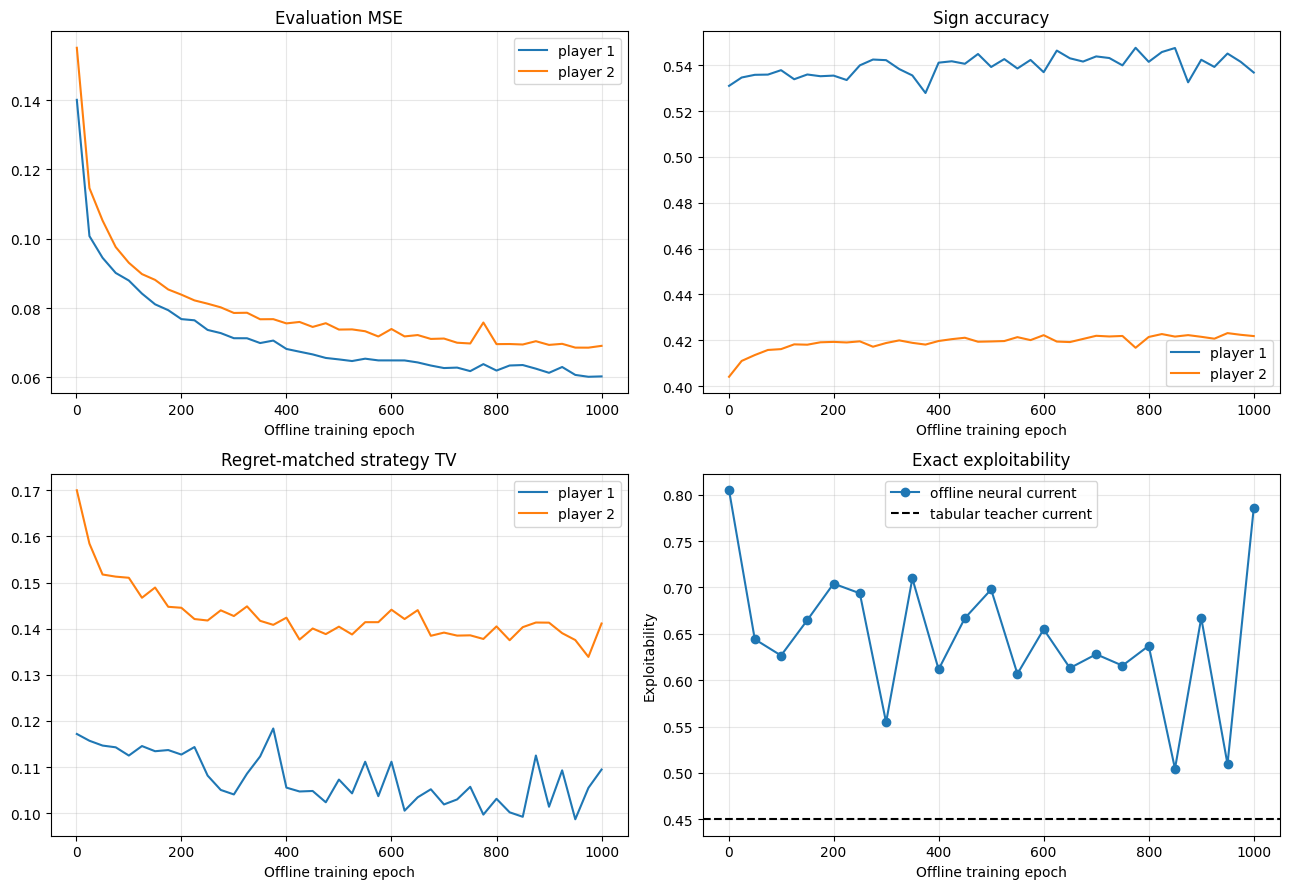

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = [('mse', 'Evaluation MSE'), ('sign_accuracy', 'Sign accuracy'), ('strategy_tv', 'Regret-matched strategy TV')]
for ax, (key, title) in zip(axes.flat[:3], metrics):
    for pid, history in enumerate(offline_histories):
        ax.plot([point['epoch'] for point in history], [point[key] for point in history], label=f'player {pid + 1}')
    ax.set(title=title, xlabel='Offline training epoch')
    ax.grid(True, alpha=0.3)
    ax.legend()

ax = axes.flat[3]
ax.plot(
    [point['epoch'] for point in offline_exact_history],
    [point['exploitability'] for point in offline_exact_history],
    marker='o',
    label='offline neural current',
)
ax.axhline(teacher_current_exploitability, color='black', linestyle='--', label='tabular teacher current')
ax.set(title='Exact exploitability', xlabel='Offline training epoch', ylabel='Exploitability')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout();

### B and C: capacity versus direct strategy distillation

Experiment B asks whether a substantially larger regret network can reproduce the fixed teacher. Experiment C bypasses regret prediction entirely and directly distills the teacher's regret-matched strategy into a small strategy network. Both train on every teacher row; this is a representation and optimization test, not a generalization test.

In [62]:
def exact_history_from_regret_snapshots(snapshots, config):
    epochs = sorted(set(snapshots[0]) & set(snapshots[1]))
    history = []
    for epoch in epochs:
        models = []
        for pid in (0, 1):
            model = NeuralMLP(teacher_encoder.input_dim, teacher_encoder.action_dim, config['hidden_sizes'])
            model.load_state_dict(snapshots[pid][epoch])
            models.append(model)
        policy = compile_offline_current_policy(models)
        history.append({'epoch': epoch, 'exploitability': exact_exploitability(policy)})
        print(f'larger regret network epoch {epoch}: exploitability={history[-1]["exploitability"]:.6f}')
    return history

larger_regret_config = {
    'hidden_sizes': (256, 256),
    'epochs': 1000,
    'batch_size': 256,
    'learning_rate': 1e-3,
    'train_fraction': 1.0,
    'snapshot_every': 200,
    'eval_every': 25,
}
larger_regret_models, larger_regret_histories, larger_regret_snapshots = [], [], []
for pid, data in enumerate(teacher_datasets):
    model, history, snapshots = fit_offline_advantage_model(data, seed=200 + pid, **larger_regret_config)
    larger_regret_models.append(model)
    larger_regret_histories.append(history)
    larger_regret_snapshots.append(snapshots)
    print(f'larger regret player {pid + 1}: final metrics = {history[-1]}')

larger_regret_exact_history = exact_history_from_regret_snapshots(larger_regret_snapshots, larger_regret_config)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [63]:
def fit_offline_strategy_model(
    data,
    *,
    hidden_sizes=(64, 64),
    epochs=1000,
    batch_size=256,
    learning_rate=1e-3,
    snapshot_every=50,
    eval_every=10,
    seed=0,
):
    torch.manual_seed(seed)
    x = torch.as_tensor(data['x'], dtype=torch.float32)
    mask = torch.as_tensor(data['mask'], dtype=torch.bool)
    target_np = regret_matched_strategy(data['y'], data['mask'])
    target = torch.as_tensor(target_np, dtype=torch.float32)
    active = data['active']
    model = NeuralMLP(teacher_encoder.input_dim, teacher_encoder.action_dim, hidden_sizes)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history, snapshots = [], {}

    for epoch in range(1, epochs + 1):
        print(epoch)
        model.train()
        order = torch.randperm(len(x))
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            logits = model(x[idx]).masked_fill(~mask[idx], -1e9)
            loss = -(target[idx] * torch.log_softmax(logits, dim=1)).sum(dim=1).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch == 1 or epoch % snapshot_every == 0 or epoch == epochs:
            snapshots[epoch] = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        if epoch == 1 or epoch % eval_every == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                logits = model(x).masked_fill(~mask, -1e9)
                probs = torch.softmax(logits, dim=1).numpy()
                cross_entropy = float(-(target * torch.log_softmax(logits, dim=1)).sum(dim=1).mean())
            row_tv = 0.5 * np.abs(probs - target_np).sum(axis=1)
            history.append({
                'epoch': epoch,
                'cross_entropy': cross_entropy,
                'strategy_tv': float(row_tv.mean()),
                'active_strategy_tv': float(row_tv[active].mean()),
                'zero_strategy_tv': float(row_tv[~active].mean()),
            })
    return model, history, snapshots

strategy_distillation_config = {
    'hidden_sizes': (64, 64),
    'epochs': 1000,
    'batch_size': 256,
    'learning_rate': 1e-3,
    'snapshot_every': 50,
    'eval_every': 10,
}
strategy_models, strategy_histories, strategy_snapshots = [], [], []
for pid, data in enumerate(teacher_datasets):
    model, history, snapshots = fit_offline_strategy_model(data, seed=300 + pid, **strategy_distillation_config)
    strategy_models.append(model)
    strategy_histories.append(history)
    strategy_snapshots.append(snapshots)
    print(f'direct strategy player {pid + 1}: final metrics = {history[-1]}')

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [64]:
def compile_offline_strategy_policy(models):
    policy = DenseTabularPolicy(spec)
    for hid in range(policy.S.shape[0]):
        pid = policy.pid_to_act(hid)
        history = hid_to_history(hid, policy.k)
        x = torch.as_tensor(teacher_encoder.encode_hands(policy.hands, history), dtype=torch.float32)
        models[pid].eval()
        with torch.no_grad():
            logits = models[pid](x)
            mask = torch.as_tensor(np.broadcast_to(policy.legal_mask[hid], logits.shape), dtype=torch.bool)
            probs = torch.softmax(logits.masked_fill(~mask, -1e9), dim=1).numpy()
        policy.S[hid] = probs
    policy.recompute_likelihoods()
    return policy

def exact_history_from_strategy_snapshots(snapshots, config):
    epochs = sorted(set(snapshots[0]) & set(snapshots[1]))
    history = []
    for epoch in epochs:
        models = []
        for pid in (0, 1):
            model = NeuralMLP(teacher_encoder.input_dim, teacher_encoder.action_dim, config['hidden_sizes'])
            model.load_state_dict(snapshots[pid][epoch])
            models.append(model)
        policy = compile_offline_strategy_policy(models)
        history.append({'epoch': epoch, 'exploitability': exact_exploitability(policy)})
        print(f'direct strategy epoch {epoch}: exploitability={history[-1]["exploitability"]:.6f}')
    return history

strategy_exact_history = exact_history_from_strategy_snapshots(strategy_snapshots, strategy_distillation_config)

direct strategy epoch 1: exploitability=0.719738
direct strategy epoch 50: exploitability=0.291548
direct strategy epoch 100: exploitability=0.355742
direct strategy epoch 150: exploitability=0.383018
direct strategy epoch 200: exploitability=0.354731
direct strategy epoch 250: exploitability=0.394322
direct strategy epoch 300: exploitability=0.411369
direct strategy epoch 350: exploitability=0.438771
direct strategy epoch 400: exploitability=0.410278
direct strategy epoch 450: exploitability=0.435237
direct strategy epoch 500: exploitability=0.415717
direct strategy epoch 550: exploitability=0.453165
direct strategy epoch 600: exploitability=0.413054
direct strategy epoch 650: exploitability=0.458083
direct strategy epoch 700: exploitability=0.435266
direct strategy epoch 750: exploitability=0.439389
direct strategy epoch 800: exploitability=0.460856
direct strategy epoch 850: exploitability=0.416830
direct strategy epoch 900: exploitability=0.455765
direct strategy epoch 950: exploit

,final exploitability,best exploitability,all strategy TV,active-row strategy TV,zero-row strategy TV,parameters per player
method,,,,,,
"A: regret (64, 64)",0.785823,0.504584,0.125284,0.113903,0.126993,6093
"B: regret (256, 256)",0.724554,0.558839,0.086781,0.031664,0.110350,73485
"C: direct strategy (64, 64)",0.437695,0.291548,0.049046,0.078011,0.036454,6093


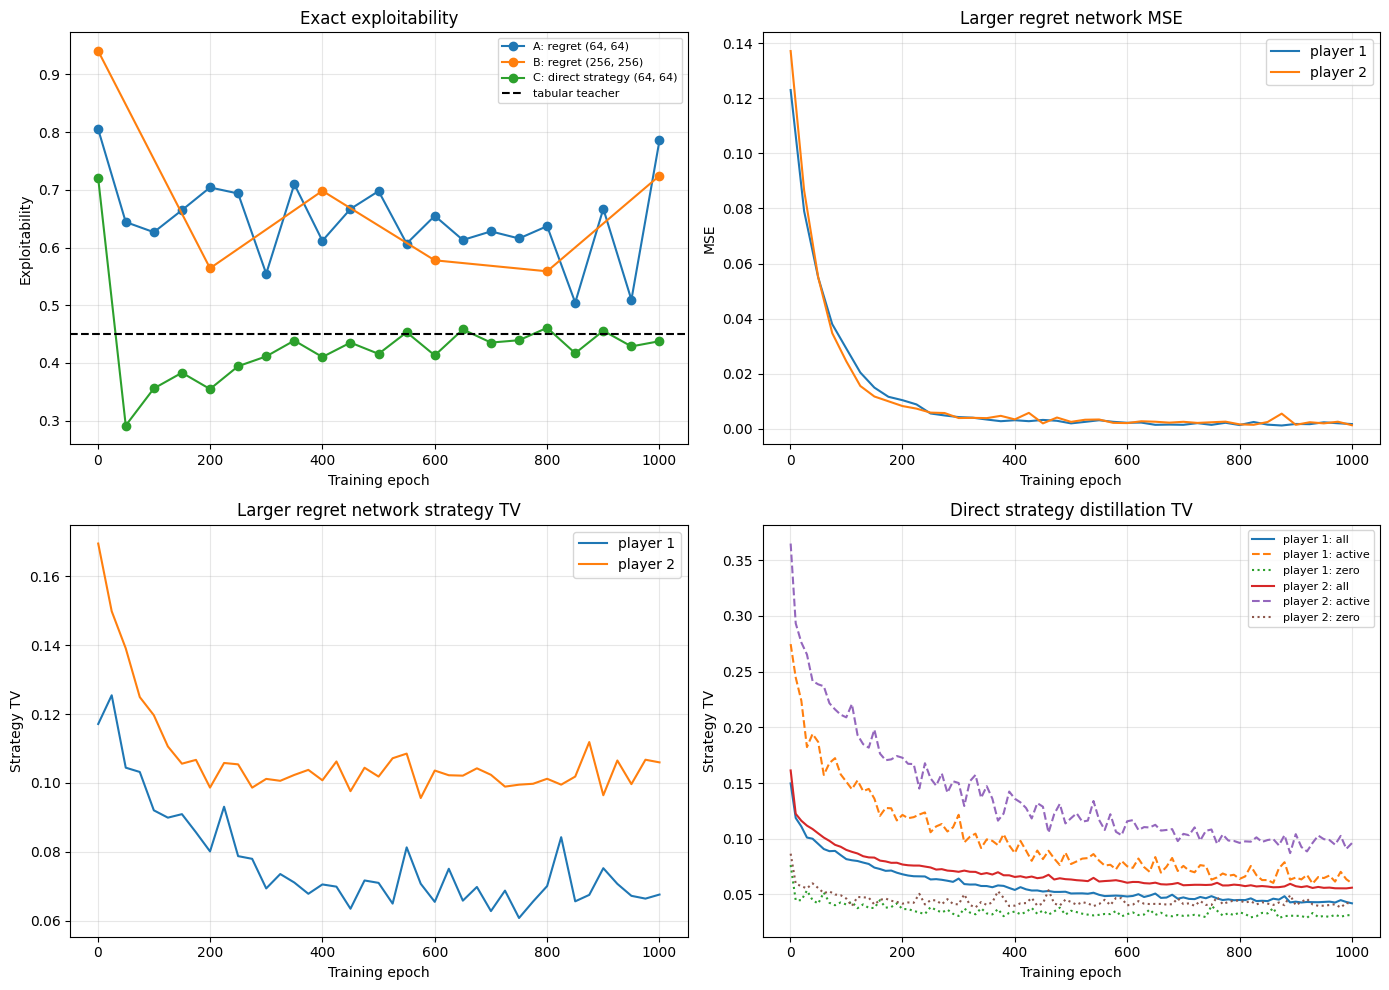

In [65]:
def final_induced_strategy_tv(models, *, direct_strategy):
    rows = []
    for pid, data in enumerate(teacher_datasets):
        x = torch.as_tensor(data['x'], dtype=torch.float32)
        models[pid].eval()
        with torch.no_grad():
            output = models[pid](x).numpy()
        if direct_strategy:
            logits = torch.as_tensor(output).masked_fill(~torch.as_tensor(data['mask']), -1e9)
            predicted = torch.softmax(logits, dim=1).numpy()
        else:
            predicted = regret_matched_strategy(output, data['mask'])
        target = regret_matched_strategy(data['y'], data['mask'])
        row_tv = 0.5 * np.abs(predicted - target).sum(axis=1)
        rows.append({
            'all strategy TV': float(row_tv.mean()),
            'active-row strategy TV': float(row_tv[data['active']].mean()),
            'zero-row strategy TV': float(row_tv[~data['active']].mean()),
        })
    return {key: float(np.mean([row[key] for row in rows])) for key in rows[0]}

comparison_rows = []
for label, models, history, direct in (
    ('A: regret (64, 64)', offline_models, offline_exact_history, False),
    ('B: regret (256, 256)', larger_regret_models, larger_regret_exact_history, False),
    ('C: direct strategy (64, 64)', strategy_models, strategy_exact_history, True),
):
    values = np.asarray([point['exploitability'] for point in history])
    comparison_rows.append({
        'method': label,
        'final exploitability': values[-1],
        'best exploitability': values.min(),
        **final_induced_strategy_tv(models, direct_strategy=direct),
        'parameters per player': sum(parameter.numel() for parameter in models[0].parameters()),
    })

teacher_comparison = pd.DataFrame(comparison_rows).set_index('method')
display(teacher_comparison.style.format(precision=6))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for label, history in (
    ('A: regret (64, 64)', offline_exact_history),
    ('B: regret (256, 256)', larger_regret_exact_history),
    ('C: direct strategy (64, 64)', strategy_exact_history),
):
    axes[0, 0].plot([point['epoch'] for point in history], [point['exploitability'] for point in history], marker='o', label=label)
axes[0, 0].axhline(teacher_current_exploitability, color='black', linestyle='--', label='tabular teacher')
axes[0, 0].set(title='Exact exploitability', xlabel='Training epoch', ylabel='Exploitability')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)
for pid, history in enumerate(larger_regret_histories):
    axes[0, 1].plot([point['epoch'] for point in history], [point['mse'] for point in history], label=f'player {pid + 1}')
    axes[1, 0].plot([point['epoch'] for point in history], [point['strategy_tv'] for point in history], label=f'player {pid + 1}')
axes[0, 1].set(title='Larger regret network MSE', xlabel='Training epoch', ylabel='MSE')
axes[1, 0].set(title='Larger regret network strategy TV', xlabel='Training epoch', ylabel='Strategy TV')
for ax in (axes[0, 1], axes[1, 0]):
    ax.grid(True, alpha=0.3)
    ax.legend()
for pid, history in enumerate(strategy_histories):
    axes[1, 1].plot([point['epoch'] for point in history], [point['strategy_tv'] for point in history], label=f'player {pid + 1}: all')
    axes[1, 1].plot([point['epoch'] for point in history], [point['active_strategy_tv'] for point in history], '--', label=f'player {pid + 1}: active')
    axes[1, 1].plot([point['epoch'] for point in history], [point['zero_strategy_tv'] for point in history], ':', label=f'player {pid + 1}: zero')
axes[1, 1].set(title='Direct strategy distillation TV', xlabel='Training epoch', ylabel='Strategy TV')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)
fig.tight_layout();

## Timed Deep CFR implementation comparison

Each variant receives 60 seconds of training for each of three seeds. Exact evaluations are excluded from the training budget, so this represents nine training-minutes plus evaluation overhead. Scratch retraining receives more advantage-fit steps because each iteration starts from a fresh network.

In [16]:
ablation_training_seconds = 60
ablation_traversals_per_player = 50
ablation_eval_every = 5
ablation_seeds = (7, 17, 27)

ablation_common = {
    'hidden_sizes': (64, 64),
    'advantage_buffer_capacity': 50_000,
    'strategy_buffer_capacity': 50_000,
    'advantage_train_steps': 100,
    'strategy_train_steps': 100,
    'batch_size': 128,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
}

ablation_variants = {
    'legacy: uniform + simultaneous': {
        'highest_regret_fallback': False,
        'alternating_updates': False,
        'retrain_advantage_from_scratch': False,
    },
    'alternating defaults': {
        'highest_regret_fallback': True,
        'alternating_updates': True,
        'retrain_advantage_from_scratch': False,
    },
    'alternating + scratch retraining': {
        'highest_regret_fallback': True,
        'alternating_updates': True,
        'retrain_advantage_from_scratch': True,
        'advantage_train_steps': 500,
    },
}

ablation_runs = []
for label, switches in ablation_variants.items():
    for seed in ablation_seeds:
        print(f'\n=== {label}; seed={seed} ===')
        policy, logs, trainer = deep_cfr_timed_loop(
            spec,
            training_seconds=ablation_training_seconds,
            traversals_per_player=ablation_traversals_per_player,
            eval_every=ablation_eval_every,
            trainer_kwargs={**ablation_common, **switches, 'seed': seed},
            debug=True,
        )
        ablation_runs.append({'variant': label, 'seed': seed, 'policy': policy, 'logs': logs, 'trainer': trainer})


=== legacy: uniform + simultaneous; seed=7 ===
[deep-cfr] iter=1 training_budget=1.93/60.00s traverse=0.53s fit=1.40s
[deep-cfr] iter=2 training_budget=3.69/60.00s traverse=0.41s fit=1.36s
[deep-cfr] iter=3 training_budget=5.63/60.00s traverse=0.54s fit=1.40s
[deep-cfr] iter=4 training_budget=7.81/60.00s traverse=0.63s fit=1.54s
[deep-cfr] iter=5 training_budget=9.77/60.00s traverse=0.56s fit=1.40s
[deep-cfr] iter=6 training_budget=11.80/60.00s traverse=0.63s fit=1.40s
[deep-cfr] iter=7 training_budget=13.88/60.00s traverse=0.57s fit=1.50s
[deep-cfr] iter=8 training_budget=15.76/60.00s traverse=0.54s fit=1.34s
[deep-cfr] iter=9 training_budget=17.62/60.00s traverse=0.48s fit=1.38s
[deep-cfr] iter=10 training_budget=19.57/60.00s traverse=0.56s fit=1.38s
[deep-cfr] iter=11 training_budget=21.50/60.00s traverse=0.49s fit=1.45s
[deep-cfr] iter=12 training_budget=23.44/60.00s traverse=0.52s fit=1.41s
[deep-cfr] iter=13 training_budget=25.35/60.00s traverse=0.53s fit=1.38s
[deep-cfr] iter=1

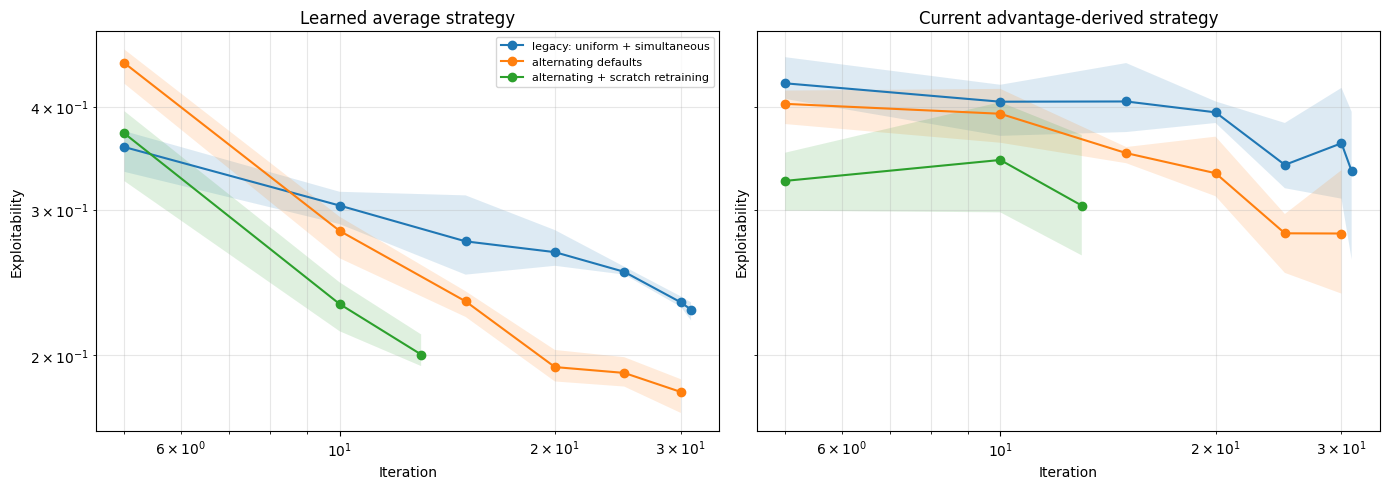

In [17]:
def aggregate_ablation_series(runs, key):
    common_iters = sorted(set.intersection(*[
        {point['iter'] for point in run['logs']['exploitability_series']}
        for run in runs
    ]))
    values = np.asarray([
        [2 * {point['iter']: point[key] for point in run['logs']['exploitability_series']}[iteration] - 1 for iteration in common_iters]
        for run in runs
    ])
    return np.asarray(common_iters), values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for label in ablation_variants:
    variant_runs = [run for run in ablation_runs if run['variant'] == label]
    for ax, key in zip(axes, ('predicted_avg', 'current_predicted_avg')):
        x, values = aggregate_ablation_series(variant_runs, key)
        mean = values.mean(axis=0)
        ax.plot(x, mean, marker='o', label=label)
        ax.fill_between(x, values.min(axis=0), values.max(axis=0), alpha=0.15)

for ax, title in zip(axes, ('Learned average strategy', 'Current advantage-derived strategy')):
    ax.set(xscale='log', yscale='log', xlabel='Iteration', ylabel='Exploitability', title=title)
    ax.grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=8)
fig.tight_layout();

In [12]:
ablation_summary = []
for run in ablation_runs:
    label = run['variant']
    series = run['logs']['exploitability_series']
    average = np.asarray([2 * point['predicted_avg'] - 1 for point in series])
    current = np.asarray([2 * point['current_predicted_avg'] - 1 for point in series])
    ablation_summary.append({
        'variant': label,
        'seed': run['seed'],
        'iterations completed': run['trainer'].iteration,
        'final average exploitability': average[-1],
        'best average exploitability': average.min(),
        'final current exploitability': current[-1],
        'best current exploitability': current.min(),
        'mean traversal s': np.mean([point['timing']['traversal_s'] for point in run['logs']['training_series']]),
        'mean advantage fit s': np.mean([point['timing']['advantage_training_s'] for point in run['logs']['training_series']]),
    })

ablation_by_run = pd.DataFrame(ablation_summary).set_index(['variant', 'seed'])
ablation_by_variant = ablation_by_run.groupby(level='variant').agg(['mean', 'std'])
display(ablation_by_variant.style.format('{:.6f}'))
ablation_by_run.style.format('{:.6f}')

,final average exploitability,best average exploitability,final current exploitability,best current exploitability,mean traversal s,mean advantage fit s
variant,,,,,,
legacy: uniform + simultaneous,0.169602,0.169602,0.408908,0.300154,0.568373,0.726941
+ highest-regret fallback,0.178256,0.168141,0.439073,0.358191,0.567132,0.692947
+ alternating updates (new default),0.145061,0.131155,0.354151,0.237225,0.611387,0.707705
+ retrain advantages from scratch,0.264630,0.228064,0.375464,0.201986,0.702939,0.709133


## Six-hour larger-game run

This runs the alternating-default Deep CFR configuration for three independent seeds, with two training-hours per seed. Exact BR evaluation is excluded from each training budget. Seed 7 additionally tracks the exact dense average of iteration strategies, which provides the cleanest diagnosis of whether any plateau comes from generated strategies or the learned average-strategy network.

Each completed run is saved immediately before its large trainer buffers are released. Expect total wall-clock time to exceed six hours because exact evaluation and seed 7's exact averaging are outside the training budget.

In [36]:
import gc
from datetime import datetime

long_spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=2,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)
long_training_seconds = 60*60
long_seeds = (7, 17, 27)
long_exact_average_seed = 7
long_traversals_per_player = 50
long_eval_every = 10

long_trainer_kwargs = {
    'hidden_sizes': (128, 128),
    'advantage_buffer_capacity': 500_000,
    'strategy_buffer_capacity': 500_000,
    'advantage_train_steps': 100,
    'strategy_train_steps': 100,
    'batch_size': 256,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
    'highest_regret_fallback': True,
    'alternating_updates': True,
    'retrain_advantage_from_scratch': False,
    'validation_fraction': 0.02,
    'validation_buffer_capacity': 20_000,
}

long_run_stamp = datetime.now().strftime('%Y%m%d-%H%M%S')
long_run_root = REPO_ROOT / 'artifacts' / 'deep_cfr_long_runs' / f'{long_spec.to_short_str()}___{long_run_stamp}'
long_spec, long_run_root

(GameSpec(ranks=4, suits=4, hand_size=2, claim_kinds=('RankHigh', 'Pair', 'Trips'), suit_symmetry=True),
 WindowsPath('C:/Users/adidh/Documents/liars_poker/artifacts/deep_cfr_long_runs/r4_s4_h2_hpt_ss___20260614-031920'))

In [37]:
long_runs = []

for seed in long_seeds:
    print(f'\n=== long run seed={seed}; exact average={seed == long_exact_average_seed} ===')
    exact_averager = ExactDenseStrategyAverager(long_spec) if seed == long_exact_average_seed else None
    policy, logs, trainer = deep_cfr_timed_loop(
        long_spec,
        training_seconds=long_training_seconds,
        traversals_per_player=long_traversals_per_player,
        eval_every=long_eval_every,
        exact_averager=exact_averager,
        trainer_kwargs={**long_trainer_kwargs, 'seed': seed},
        debug=True,
    )

    run_dir = long_run_root / f'seed_{seed}'
    save_deep_cfr_run(run_dir, policy=policy, trainer=trainer, logs=logs)
    long_runs.append({
        'seed': seed,
        'policy': policy,
        'logs': logs,
        'run_dir': run_dir,
        'exact_average_tracked': exact_averager is not None,
    })
    print(f'saved {run_dir}')
    del trainer, exact_averager
    gc.collect()


=== long run seed=7; exact average=True ===
[deep-cfr] iter=1 training_budget=2.11/3600.00s traverse=0.54s fit=1.58s
[deep-cfr] iter=2 training_budget=5.46/3600.00s traverse=1.61s fit=1.73s
[deep-cfr] iter=3 training_budget=8.34/3600.00s traverse=1.19s fit=1.70s
[deep-cfr] iter=4 training_budget=11.30/3600.00s traverse=1.21s fit=1.75s
[deep-cfr] iter=5 training_budget=14.18/3600.00s traverse=1.15s fit=1.73s
[deep-cfr] iter=6 training_budget=17.30/3600.00s traverse=1.34s fit=1.78s
[deep-cfr] iter=7 training_budget=20.46/3600.00s traverse=1.27s fit=1.89s
[deep-cfr] iter=8 training_budget=23.44/3600.00s traverse=1.23s fit=1.76s
[deep-cfr] iter=9 training_budget=26.52/3600.00s traverse=1.30s fit=1.78s
[deep-cfr] iter=10 training_budget=29.56/3600.00s traverse=1.24s fit=1.80s
[deep-cfr] iter=11 training_budget=32.49/3600.00s traverse=1.20s fit=1.73s
[deep-cfr] iter=12 training_budget=35.53/3600.00s traverse=1.28s fit=1.75s
[deep-cfr] iter=13 training_budget=38.51/3600.00s traverse=1.21s fi

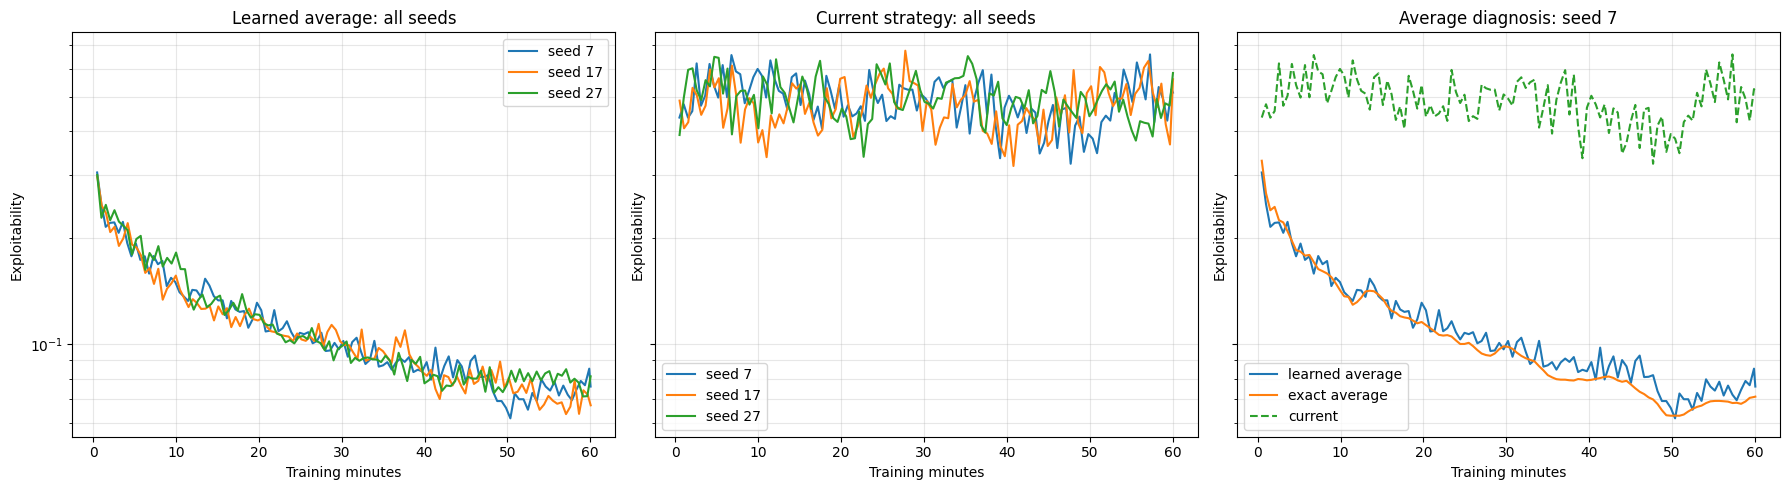

In [38]:
def exploitability_from_point(point, key):
    return max(2 * point[key] - 1, 1e-8)

def evaluation_minutes(run):
    elapsed_by_iter = {record['iteration']: record['elapsed_s'] / 60 for record in run['logs']['training_series']}
    return np.asarray([elapsed_by_iter[point['iter']] for point in run['logs']['exploitability_series']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for run in long_runs:
    series = run['logs']['exploitability_series']
    minutes = evaluation_minutes(run)
    axes[0].plot(minutes, [exploitability_from_point(point, 'predicted_avg') for point in series], label=f"seed {run['seed']}")
    axes[1].plot(minutes, [exploitability_from_point(point, 'current_predicted_avg') for point in series], label=f"seed {run['seed']}")

exact_run = next(run for run in long_runs if run['exact_average_tracked'])
exact_series = exact_run['logs']['exploitability_series']
exact_minutes = evaluation_minutes(exact_run)
axes[2].plot(exact_minutes, [exploitability_from_point(point, 'predicted_avg') for point in exact_series], label='learned average')
axes[2].plot(exact_minutes, [exploitability_from_point(point, 'exact_average_predicted_avg') for point in exact_series], label='exact average')
axes[2].plot(exact_minutes, [exploitability_from_point(point, 'current_predicted_avg') for point in exact_series], '--', label='current')

for ax, title in zip(axes, ('Learned average: all seeds', 'Current strategy: all seeds', f'Average diagnosis: seed {long_exact_average_seed}')):
    ax.set(yscale='log', xlabel='Training minutes', ylabel='Exploitability', title=title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
fig.tight_layout();

In [39]:
def final_validation_mean(run, family, key):
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    if not records:
        return np.nan
    return float(np.mean([player[key] for player in records[-1]['validation'][family] if key in player]))

long_summary = []
for run in long_runs:
    training = run['logs']['training_series']
    series = run['logs']['exploitability_series']
    final = training[-1]
    retained = sum(final['advantage_buffer_sizes']) + sum(final['strategy_buffer_sizes'])
    seen = sum(final['advantage_records_seen']) + sum(final['strategy_records_seen'])
    average = np.asarray([2 * point['predicted_avg'] - 1 for point in series])
    current = np.asarray([2 * point['current_predicted_avg'] - 1 for point in series])
    exact_values = np.asarray([
        2 * point['exact_average_predicted_avg'] - 1
        for point in series
        if 'exact_average_predicted_avg' in point
    ])
    long_summary.append({
        'seed': run['seed'],
        'iterations completed': final['iteration'],
        'final learned-average exploitability': average[-1],
        'best learned-average exploitability': average.min(),
        'final current exploitability': current[-1],
        'best current exploitability': current.min(),
        'final exact-average exploitability': exact_values[-1] if len(exact_values) else np.nan,
        'best exact-average exploitability': exact_values.min() if len(exact_values) else np.nan,
        'final advantage validation MSE': final_validation_mean(run, 'advantage', 'mse'),
        'final advantage strategy TV': final_validation_mean(run, 'advantage', 'strategy_tv'),
        'final average-network strategy TV': final_validation_mean(run, 'strategy', 'strategy_tv'),
        'records retained fraction': retained / seen,
        'mean traversal s': np.mean([record['timing']['traversal_s'] for record in training]),
        'mean advantage fit s': np.mean([record['timing']['advantage_training_s'] for record in training]),
        'mean strategy fit s': np.mean([record['timing']['strategy_training_s'] for record in training]),
        'run directory': str(run['run_dir']),
    })

long_summary_df = pd.DataFrame(long_summary).set_index('seed')
long_summary_df.style.format(precision=6)

,iterations completed,final learned-average exploitability,best learned-average exploitability,final current exploitability,best current exploitability,final exact-average exploitability,best exact-average exploitability,final advantage validation MSE,final advantage strategy TV,final average-network strategy TV,records retained fraction,mean traversal s,mean advantage fit s,mean strategy fit s,run directory
seed,,,,,,,,,,,,,,,
7,1143,0.075936,0.061754,0.513627,0.323392,0.071111,0.062801,0.669929,0.328951,0.096226,0.334912,1.355931,0.895832,0.899629,C:\Users\adidh\Documents\liars_poker\artifacts\deep_cfr_long_runs\r4_s4_h2_hpt_ss___20260614-031920\seed_7
17,1147,0.067213,0.063476,0.560318,0.318715,nan,nan,0.662324,0.328305,0.111899,0.338853,1.332872,0.907002,0.901229,C:\Users\adidh\Documents\liars_poker\artifacts\deep_cfr_long_runs\r4_s4_h2_hpt_ss___20260614-031920\seed_17
27,1148,0.081163,0.071191,0.583458,0.338316,nan,nan,0.645668,0.352801,0.095098,0.340411,1.324321,0.909429,0.904340,C:\Users\adidh\Documents\liars_poker\artifacts\deep_cfr_long_runs\r4_s4_h2_hpt_ss___20260614-031920\seed_27


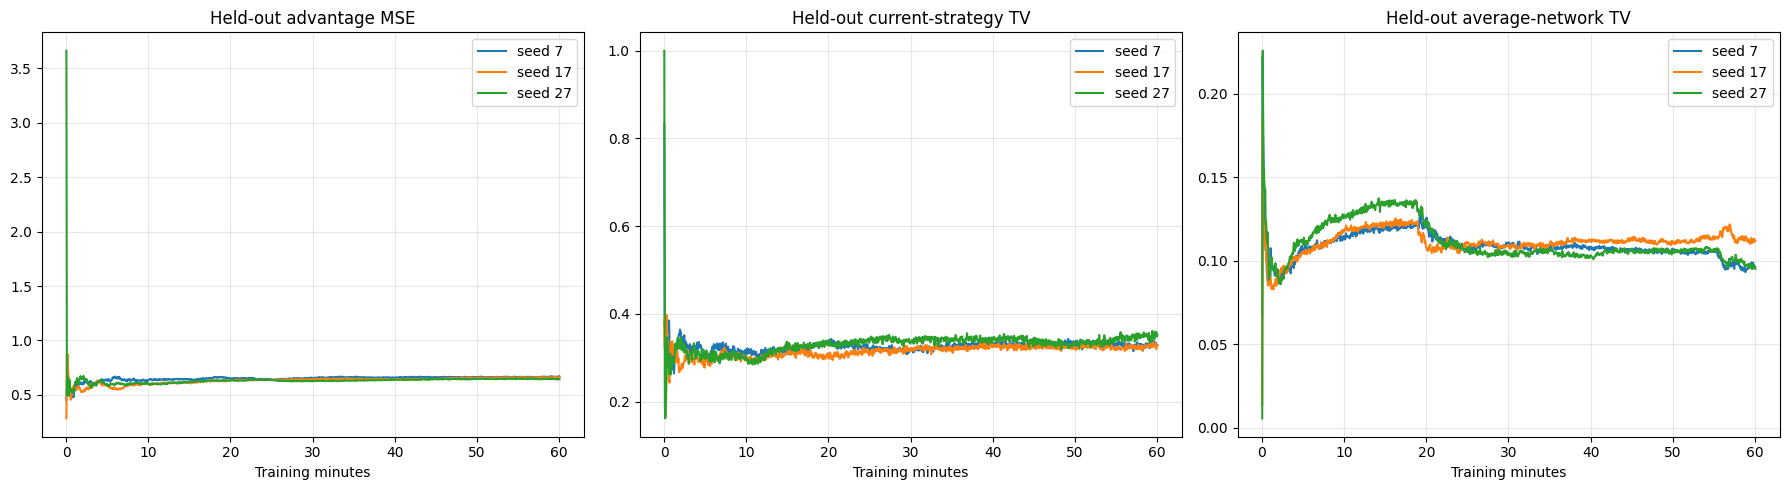

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
diagnostic_specs = [
    ('advantage', 'mse', 'Held-out advantage MSE'),
    ('advantage', 'strategy_tv', 'Held-out current-strategy TV'),
    ('strategy', 'strategy_tv', 'Held-out average-network TV'),
]
for run in long_runs:
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    minutes = [record['elapsed_s'] / 60 for record in records]
    for ax, (family, key, title) in zip(axes, diagnostic_specs):
        values = [np.mean([player[key] for player in record['validation'][family] if key in player]) for record in records]
        ax.plot(minutes, values, label=f"seed {run['seed']}")
        ax.set(title=title, xlabel='Training minutes')
        ax.grid(True, alpha=0.3)
for ax in axes:
    ax.legend()
fig.tight_layout();

## Online neural-strategy student diagnostic

This experiment keeps cumulative regrets in the trusted tabular external-sampling CFR implementation, then trains a neural network to directly imitate the tabular regret-matched **current strategy** after every iteration.

- **Tabular baseline:** tabular current strategy drives traversals.
- **Shadow student:** traversals remain tabular; the neural student only tries to track the moving teacher.
- **Closed-loop hybrid:** regrets remain tabular, but the neural student drives future traversals and is accumulated into the average strategy.

The shadow run tests whether the network can track an online moving target. The closed-loop run tests whether the resulting approximation errors create a harmful traversal-feedback loop. The shadow run's accumulated average is exactly the tabular baseline average because its student never affects play; it is plotted separately only to make that identity explicit. This is deliberately a small-game diagnostic, not a scalable algorithm.


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.algo.cfr_external_sampling_dense import CFRExternalSamplingDense
from liars_poker.policies.neural import InfosetEncoder, NeuralMLP
from liars_poker.policies.tabular_dense import DenseTabularPolicy


class OnlineStrategyStudentCFR(CFRExternalSamplingDense):
    """Tabular regrets with an optional neural current strategy in the traversal loop."""

    def __init__(
        self,
        spec,
        *,
        use_student_for_traversal,
        hidden_sizes=(64, 64),
        learning_rate=1e-3,
        fit_steps=100,
        batch_size=256,
        seed=0,
    ):
        super().__init__(spec, seed=seed, strategy_weighting='linear')
        self.use_student_for_traversal = use_student_for_traversal
        self.encoder = InfosetEncoder(spec)
        self.fit_steps = fit_steps
        self.batch_size = batch_size
        self.student_rng = np.random.default_rng(seed + 10_000)
        torch.manual_seed(seed + 20_000)
        self.student_models = [
            NeuralMLP(self.encoder.input_dim, self.encoder.action_dim, hidden_sizes)
            for _ in range(2)
        ]
        self.student_optimizers = [
            torch.optim.Adam(model.parameters(), lr=learning_rate)
            for model in self.student_models
        ]
        self.student_rows = [self._build_student_rows(pid) for pid in (0, 1)]

    def _build_student_rows(self, pid):
        features, hids, hand_indices, masks = [], [], [], []
        for hid in range(self.H):
            if (hid.bit_count() & 1) != pid:
                continue
            history = hid_to_history(hid, self.k)
            features.append(self.encoder.encode_hands(self.hands, history))
            hids.append(np.full(self.n_hands, hid, dtype=np.int64))
            hand_indices.append(np.arange(self.n_hands, dtype=np.int64))
            masks.append(np.broadcast_to(self.legal_mask[hid], (self.n_hands, self.A)))
        return {
            'x': np.concatenate(features),
            'hid': np.concatenate(hids),
            'hand_idx': np.concatenate(hand_indices),
            'mask': np.concatenate(masks).copy(),
        }

    @staticmethod
    def _regret_match_rows(regrets, mask):
        positive = np.maximum(regrets, 0.0) * mask
        totals = positive.sum(axis=1, keepdims=True)
        strategy = np.divide(positive, totals, out=np.zeros_like(positive), where=totals > 0.0)
        fallback = totals[:, 0] <= 0.0
        strategy[fallback] = mask[fallback] / mask[fallback].sum(axis=1, keepdims=True)
        return strategy

    def _teacher_targets(self, pid, indices=None):
        rows = self.student_rows[pid]
        if indices is None:
            indices = np.arange(len(rows['x']))
        regrets = (self.R0 if pid == 0 else self.R1)[rows['hid'][indices], rows['hand_idx'][indices]]
        return self._regret_match_rows(regrets, rows['mask'][indices])

    def _student_strategy(self, pid, hid, hand_idx):
        history = hid_to_history(hid, self.k)
        x = torch.as_tensor(self.encoder.encode(self.hands[hand_idx], history), dtype=torch.float32)
        mask = torch.as_tensor(self.legal_mask[hid], dtype=torch.bool)
        self.student_models[pid].eval()
        with torch.no_grad():
            logits = self.student_models[pid](x).masked_fill(~mask, -1e9)
            return torch.softmax(logits, dim=0).numpy().astype(self.dtype, copy=False)

    def _strategy(self, pid, hid, hand_idx):
        if self.use_student_for_traversal:
            return self._student_strategy(pid, hid, hand_idx)
        return CFRExternalSamplingDense._strategy(self, pid, hid, hand_idx)

    def fit_students(self):
        losses = []
        for pid in (0, 1):
            rows = self.student_rows[pid]
            model = self.student_models[pid]
            optimizer = self.student_optimizers[pid]
            model.train()
            pid_losses = []
            for _ in range(self.fit_steps):
                indices = self.student_rng.integers(0, len(rows['x']), size=min(self.batch_size, len(rows['x'])))
                x = torch.as_tensor(rows['x'][indices], dtype=torch.float32)
                mask = torch.as_tensor(rows['mask'][indices], dtype=torch.bool)
                target = torch.as_tensor(self._teacher_targets(pid, indices), dtype=torch.float32)
                logits = model(x).masked_fill(~mask, -1e9)
                loss = -(target * torch.log_softmax(logits, dim=1)).sum(dim=1).mean()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pid_losses.append(float(loss.detach()))
            losses.append(float(np.mean(pid_losses)))
        return losses

    def teacher_current_policy(self):
        policy = DenseTabularPolicy(self.spec)
        for hid in range(self.H):
            pid = policy.pid_to_act(hid)
            regrets = (self.R0 if pid == 0 else self.R1)[hid]
            mask = np.broadcast_to(self.legal_mask[hid], regrets.shape)
            policy.S[hid] = self._regret_match_rows(regrets, mask)
        policy.recompute_likelihoods()
        return policy

    def student_current_policy(self):
        policy = DenseTabularPolicy(self.spec)
        for hid in range(self.H):
            pid = policy.pid_to_act(hid)
            history = hid_to_history(hid, self.k)
            x = torch.as_tensor(self.encoder.encode_hands(self.hands, history), dtype=torch.float32)
            mask = torch.as_tensor(np.broadcast_to(self.legal_mask[hid], (self.n_hands, self.A)).copy(), dtype=torch.bool)
            self.student_models[pid].eval()
            with torch.no_grad():
                logits = self.student_models[pid](x).masked_fill(~mask, -1e9)
                policy.S[hid] = torch.softmax(logits, dim=1).numpy()
        policy.recompute_likelihoods()
        return policy

    def student_metrics(self):
        metrics = []
        for pid in (0, 1):
            rows = self.student_rows[pid]
            x = torch.as_tensor(rows['x'], dtype=torch.float32)
            mask = torch.as_tensor(rows['mask'], dtype=torch.bool)
            target = self._teacher_targets(pid)
            self.student_models[pid].eval()
            with torch.no_grad():
                logits = self.student_models[pid](x).masked_fill(~mask, -1e9)
                predicted = torch.softmax(logits, dim=1).numpy()
            row_tv = 0.5 * np.abs(predicted - target).sum(axis=1)
            metrics.append({
                'strategy_tv': float(row_tv.mean()),
                'top_action_match': float((predicted.argmax(axis=1) == target.argmax(axis=1)).mean()),
            })
        return {
            key: float(np.mean([player[key] for player in metrics]))
            for key in metrics[0]
        }


In [11]:
hybrid_iterations = 100
hybrid_traversals_per_player = 50
hybrid_eval_every = 10
hybrid_fit_steps = 100
hybrid_seed = 7

baseline_cfr = CFRExternalSamplingDense(spec, seed=hybrid_seed, strategy_weighting='linear')
shadow_cfr = OnlineStrategyStudentCFR(
    spec,
    use_student_for_traversal=False,
    fit_steps=hybrid_fit_steps,
    seed=hybrid_seed,
)
closed_loop_cfr = OnlineStrategyStudentCFR(
    spec,
    use_student_for_traversal=True,
    fit_steps=hybrid_fit_steps,
    seed=hybrid_seed,
)

hybrid_history = []
for iteration in range(1, hybrid_iterations + 1):
    baseline_cfr.run_iteration(traversals_per_player=hybrid_traversals_per_player)
    shadow_cfr.run_iteration(traversals_per_player=hybrid_traversals_per_player)
    closed_loop_cfr.run_iteration(traversals_per_player=hybrid_traversals_per_player)
    shadow_losses = shadow_cfr.fit_students()
    closed_losses = closed_loop_cfr.fit_students()

    if iteration % hybrid_eval_every == 0 or iteration == 1:
        record = {
            'iter': iteration,
            'baseline_average': exact_exploitability(baseline_cfr.average_policy()),
            'baseline_current': exact_exploitability(baseline_cfr.current_policy()),
            'shadow_student': exact_exploitability(shadow_cfr.student_current_policy()),
            'closed_average': exact_exploitability(closed_loop_cfr.average_policy()),
            'closed_teacher_current': exact_exploitability(closed_loop_cfr.teacher_current_policy()),
            'closed_student_current': exact_exploitability(closed_loop_cfr.student_current_policy()),
            'shadow_loss': float(np.mean(shadow_losses)),
            'closed_loss': float(np.mean(closed_losses)),
        }
        record['shadow_average'] = record['baseline_average']
        record.update({f'shadow_{key}': value for key, value in shadow_cfr.student_metrics().items()})
        record.update({f'closed_{key}': value for key, value in closed_loop_cfr.student_metrics().items()})
        hybrid_history.append(record)
        print(
            f"iter={iteration:3d} baseline_avg={record['baseline_average']:.4f} "
            f"shadow_student={record['shadow_student']:.4f} "
            f"closed_avg={record['closed_average']:.4f} "
            f"closed_student={record['closed_student_current']:.4f}"
        )

# With identical seeds, shadow training must not perturb the tabular CFR trajectory.
shadow_tabular_max_diff = max(
    float(np.max(np.abs(baseline_cfr.R0 - shadow_cfr.R0))),
    float(np.max(np.abs(baseline_cfr.R1 - shadow_cfr.R1))),
    float(np.max(np.abs(baseline_cfr.SS0 - shadow_cfr.SS0))),
    float(np.max(np.abs(baseline_cfr.SS1 - shadow_cfr.SS1))),
)
assert shadow_tabular_max_diff == 0.0
print('baseline/shadow tabular-state max difference:', shadow_tabular_max_diff)


C:\Users\adidh\AppData\Local\Temp\ipykernel_18896\4075833019.py:128: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  mask = torch.as_tensor(np.broadcast_to(self.legal_mask[hid], (self.n_hands, self.A)), dtype=torch.bool)


iter=  1 baseline_avg=0.8632 shadow_student=0.8480 closed_avg=0.8607 closed_student=0.8487
iter= 10 baseline_avg=0.6202 shadow_student=0.6673 closed_avg=0.7634 closed_student=0.6987
iter= 20 baseline_avg=0.5221 shadow_student=0.5159 closed_avg=0.6635 closed_student=0.5904
iter= 30 baseline_avg=0.4131 shadow_student=0.3873 closed_avg=0.5798 closed_student=0.4630
iter= 40 baseline_avg=0.3433 shadow_student=0.3413 closed_avg=0.5092 closed_student=0.4194
iter= 50 baseline_avg=0.2898 shadow_student=0.2694 closed_avg=0.4535 closed_student=0.3873
iter= 60 baseline_avg=0.2515 shadow_student=0.2745 closed_avg=0.4082 closed_student=0.4086
iter= 70 baseline_avg=0.2234 shadow_student=0.2742 closed_avg=0.3863 closed_student=0.4027
iter= 80 baseline_avg=0.1977 shadow_student=0.2501 closed_avg=0.3752 closed_student=0.4099
iter= 90 baseline_avg=0.1725 shadow_student=0.2331 closed_avg=0.3655 closed_student=0.4194
iter=100 baseline_avg=0.1625 shadow_student=0.1999 closed_avg=0.3601 closed_student=0.3844

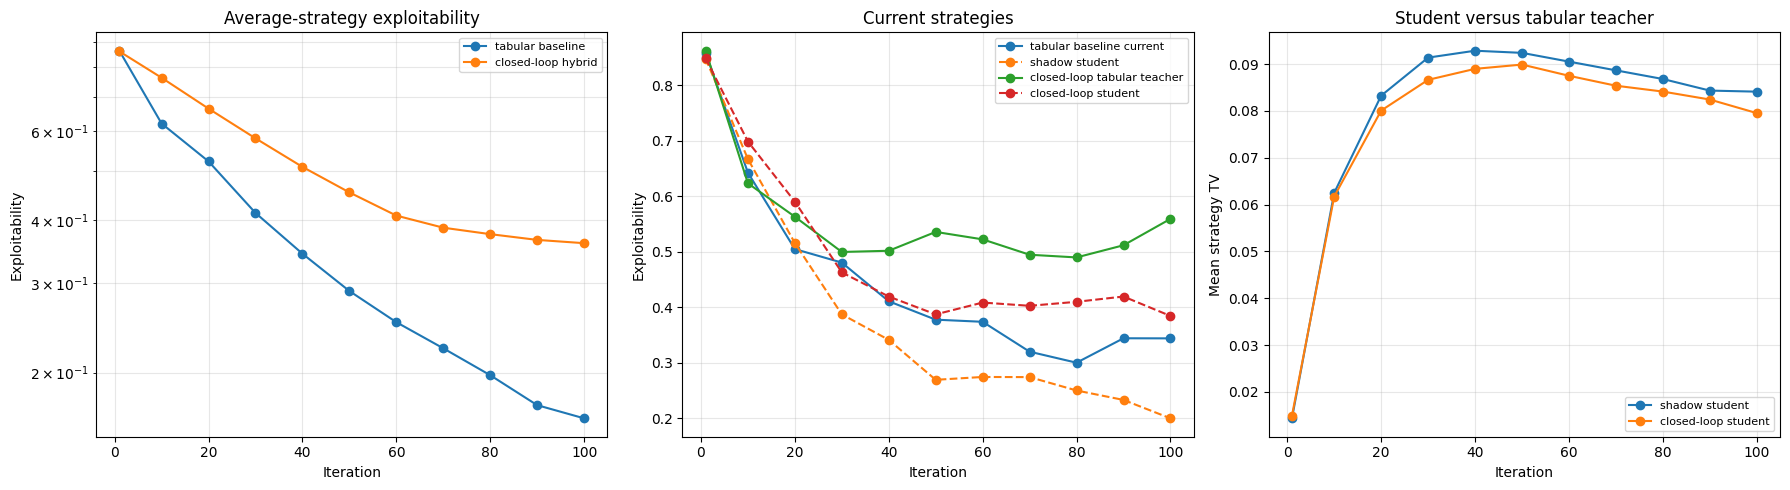

In [15]:
x = [point['iter'] for point in hybrid_history]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x, [point['baseline_average'] for point in hybrid_history], marker='o', label='tabular baseline')
# axes[0].plot(x, [point['shadow_average'] for point in hybrid_history], '--', label='shadow average (= baseline)')
axes[0].plot(x, [point['closed_average'] for point in hybrid_history], marker='o', label='closed-loop hybrid')
axes[0].set(title='Average-strategy exploitability', xlabel='Iteration', ylabel='Exploitability', yscale='log')

for key, label, style in (
    ('baseline_current', 'tabular baseline current', '-'),
    ('shadow_student', 'shadow student', '--'),
    ('closed_teacher_current', 'closed-loop tabular teacher', '-'),
    ('closed_student_current', 'closed-loop student', '--'),
):
    axes[1].plot(x, [point[key] for point in hybrid_history], style, marker='o', label=label)
axes[1].set(title='Current strategies', xlabel='Iteration', ylabel='Exploitability')

axes[2].plot(x, [point['shadow_strategy_tv'] for point in hybrid_history], marker='o', label='shadow student')
axes[2].plot(x, [point['closed_strategy_tv'] for point in hybrid_history], marker='o', label='closed-loop student')
axes[2].set(title='Student versus tabular teacher', xlabel='Iteration', ylabel='Mean strategy TV')

for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [13]:
def final_and_best(key):
    values = np.asarray([point[key] for point in hybrid_history])
    return values[-1], values.min()

hybrid_summary = pd.DataFrame([
    {
        'variant': 'tabular baseline',
        'final average exploitability': final_and_best('baseline_average')[0],
        'best average exploitability': final_and_best('baseline_average')[1],
        'final deployed-current exploitability': final_and_best('baseline_current')[0],
        'best deployed-current exploitability': final_and_best('baseline_current')[1],
        'final student-teacher TV': np.nan,
        'final top-action match': np.nan,
    },
    {
        'variant': 'shadow student',
        'final average exploitability': final_and_best('shadow_average')[0],
        'best average exploitability': final_and_best('shadow_average')[1],
        'final deployed-current exploitability': final_and_best('shadow_student')[0],
        'best deployed-current exploitability': final_and_best('shadow_student')[1],
        'final student-teacher TV': hybrid_history[-1]['shadow_strategy_tv'],
        'final top-action match': hybrid_history[-1]['shadow_top_action_match'],
    },
    {
        'variant': 'closed-loop hybrid',
        'final average exploitability': final_and_best('closed_average')[0],
        'best average exploitability': final_and_best('closed_average')[1],
        'final deployed-current exploitability': final_and_best('closed_student_current')[0],
        'best deployed-current exploitability': final_and_best('closed_student_current')[1],
        'final student-teacher TV': hybrid_history[-1]['closed_strategy_tv'],
        'final top-action match': hybrid_history[-1]['closed_top_action_match'],
    },
]).set_index('variant')

hybrid_summary.style.format(precision=6).background_gradient(
    subset=['final average exploitability', 'best average exploitability'],
    cmap='RdYlGn_r',
)


,final average exploitability,best average exploitability,final deployed-current exploitability,best deployed-current exploitability,final student-teacher TV,final top-action match
variant,,,,,,
tabular baseline,0.162503,0.162503,0.344035,0.300176,nan,nan
shadow student,0.162503,0.162503,0.199931,0.199931,0.084105,0.950952
closed-loop hybrid,0.360095,0.360095,0.384433,0.384433,0.079525,0.956274


## Epsilon exploration in the closed-loop hybrid

This tests whether the closed-loop student's approximation errors damage learning primarily by starving branches of traversal coverage. The deployed policy is mixed consistently at every decision:

`deployed = (1 - epsilon) * student + epsilon * uniform_legal`

The deployed policy controls node values, opponent sampling, and average-strategy accumulation. The comparison uses one seed and tracks both exact exploitability and traversal coverage. Exact evaluations are intentionally less frequent because they dominate runtime.

In [16]:
class VisitedExternalSamplingCFR(CFRExternalSamplingDense):
    """Tabular baseline instrumented with traversal-only infoset visit counts."""

    def __init__(self, spec, *, seed):
        super().__init__(spec, seed=seed, strategy_weighting='linear')
        self.visit_counts = np.zeros((self.H, self.n_hands), dtype=np.int64)
        self._tracking_visits = False

    def run_iteration(self, *, traversals_per_player=100):
        self._tracking_visits = True
        try:
            return super().run_iteration(traversals_per_player=traversals_per_player)
        finally:
            self._tracking_visits = False

    def _strategy(self, pid, hid, hand_idx):
        strategy = super()._strategy(pid, hid, hand_idx)
        if self._tracking_visits:
            self.visit_counts[hid, hand_idx] += 1
        return strategy


class EpsilonOnlineStrategyStudentCFR(OnlineStrategyStudentCFR):
    """Closed-loop tabular-regret/neural-strategy hybrid with uniform exploration."""

    def __init__(self, spec, *, epsilon, seed, fit_steps=100, hidden_sizes=(64, 64)):
        super().__init__(
            spec,
            use_student_for_traversal=True,
            fit_steps=fit_steps,
            hidden_sizes=hidden_sizes,
            seed=seed,
        )
        self.epsilon = float(epsilon)
        self.visit_counts = np.zeros((self.H, self.n_hands), dtype=np.int64)
        self._tracking_visits = False

    def run_iteration(self, *, traversals_per_player=100):
        self._tracking_visits = True
        try:
            return super().run_iteration(traversals_per_player=traversals_per_player)
        finally:
            self._tracking_visits = False

    def _strategy(self, pid, hid, hand_idx):
        strategy = self._student_strategy(pid, hid, hand_idx)
        if self.epsilon:
            mask = self.legal_mask[hid]
            strategy = (1.0 - self.epsilon) * strategy + self.epsilon * mask / mask.sum()
        if self._tracking_visits:
            self.visit_counts[hid, hand_idx] += 1
        return strategy

    def deployed_current_policy(self):
        policy = self.student_current_policy()
        if self.epsilon:
            for hid in range(self.H):
                mask = self.legal_mask[hid]
                policy.S[hid] = (1.0 - self.epsilon) * policy.S[hid] + self.epsilon * mask / mask.sum()
            policy.recompute_likelihoods()
        return policy

    def weighted_student_metrics(self):
        total_weight = 0.0
        weighted_tv = 0.0
        for pid in (0, 1):
            rows = self.student_rows[pid]
            x = torch.as_tensor(rows['x'], dtype=torch.float32)
            mask = torch.as_tensor(rows['mask'], dtype=torch.bool)
            target = self._teacher_targets(pid)
            self.student_models[pid].eval()
            with torch.no_grad():
                logits = self.student_models[pid](x).masked_fill(~mask, -1e9)
                predicted = torch.softmax(logits, dim=1).numpy()
            row_tv = 0.5 * np.abs(predicted - target).sum(axis=1)
            visits = self.visit_counts[rows['hid'], rows['hand_idx']].astype(float)
            weighted_tv += float(np.dot(visits, row_tv))
            total_weight += float(visits.sum())
        return weighted_tv / total_weight if total_weight else np.nan

    def coverage_metrics(self, baseline_visits):
        reached = self.visit_counts > 0
        counts = self.visit_counts[reached]
        baseline_reached = baseline_visits > 0
        return {
            'unique_infosets': int(reached.sum()),
            'median_visits': float(np.median(counts)) if len(counts) else 0.0,
            'fraction_under_5': float((counts < 5).mean()) if len(counts) else 1.0,
            'baseline_reached_missing': float((baseline_reached & ~reached).sum() / max(1, baseline_reached.sum())),
        }


In [19]:
epsilon_iterations = 150
epsilon_traversals_per_player = 50
epsilon_eval_every = 20
epsilon_fit_steps = 100
epsilon_seeds = (7,)
epsilon_values = (0.0, 0.05)

epsilon_history = []
epsilon_final_diagnostics = []

for seed in epsilon_seeds:
    print(f'\n=== epsilon exploration seed={seed} ===')
    baseline = VisitedExternalSamplingCFR(spec, seed=seed)
    variants = {
        epsilon: EpsilonOnlineStrategyStudentCFR(
            spec,
            epsilon=epsilon,
            seed=seed,
            fit_steps=epsilon_fit_steps,
        )
        for epsilon in epsilon_values
    }

    for iteration in range(1, epsilon_iterations + 1):
        print(iteration)
        baseline.run_iteration(traversals_per_player=epsilon_traversals_per_player)
        for variant in variants.values():
            variant.run_iteration(traversals_per_player=epsilon_traversals_per_player)
            variant.fit_students()

        if iteration % epsilon_eval_every == 0 or iteration == 1:
            epsilon_history.append({
                'seed': seed,
                'iter': iteration,
                'variant': 'tabular baseline',
                'average_exploitability': exact_exploitability(baseline.average_policy()),
                'deployed_current_exploitability': exact_exploitability(baseline.current_policy()),
                'student_teacher_tv': np.nan,
                'visit_weighted_tv': np.nan,
                'unique_infosets': int((baseline.visit_counts > 0).sum()),
                'baseline_reached_missing': 0.0,
            })
            for epsilon, variant in variants.items():
                coverage = variant.coverage_metrics(baseline.visit_counts)
                epsilon_history.append({
                    'seed': seed,
                    'iter': iteration,
                    'variant': f'closed loop epsilon={epsilon:g}',
                    'average_exploitability': exact_exploitability(variant.average_policy()),
                    'deployed_current_exploitability': exact_exploitability(variant.deployed_current_policy()),
                    'student_teacher_tv': variant.student_metrics()['strategy_tv'],
                    'visit_weighted_tv': variant.weighted_student_metrics(),
                    **coverage,
                })
            print(f'iter={iteration:3d}; completed exact evaluation')

    for epsilon, variant in variants.items():
        epsilon_final_diagnostics.append({
            'seed': seed,
            'variant': f'closed loop epsilon={epsilon:g}',
            'raw student exploitability': exact_exploitability(variant.student_current_policy()),
            'deployed student exploitability': exact_exploitability(variant.deployed_current_policy()),
            'tabular teacher exploitability': exact_exploitability(variant.teacher_current_policy()),
        })

epsilon_df = pd.DataFrame(epsilon_history)
epsilon_final_df = pd.DataFrame(epsilon_final_diagnostics)
epsilon_df.tail()



=== epsilon exploration seed=7 ===
1
iter=  1; completed exact evaluation
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
iter= 20; completed exact evaluation
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
iter= 40; completed exact evaluation
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
iter= 60; completed exact evaluation
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
iter= 80; completed exact evaluation
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
iter=100; completed exact evaluation
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
iter=120; completed exact evaluation
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
iter=140; completed exact evaluation
141
142
143
144
145
146
147
148
149
150


,seed,iter,variant,average_exploitability,deployed_current_exploitability,student_teacher_tv,visit_weighted_tv,unique_infosets,baseline_reached_missing,median_visits,fraction_under_5
19,7,120,closed loop epsilon=0,0.344637,0.455656,0.075345,0.096853,32691,0.110216,4.0,0.527301
20,7,120,closed loop epsilon=0.05,0.346005,0.409959,0.075840,0.086246,32546,0.111694,4.0,0.519050
21,7,140,tabular baseline,0.160097,0.420373,NaN,NaN,28942,0.000000,NaN,NaN
22,7,140,closed loop epsilon=0,0.328061,0.514404,0.071730,0.082863,33181,0.104658,4.0,0.510654
23,7,140,closed loop epsilon=0.05,0.332102,0.431952,0.072351,0.079873,33074,0.105072,4.0,0.501451


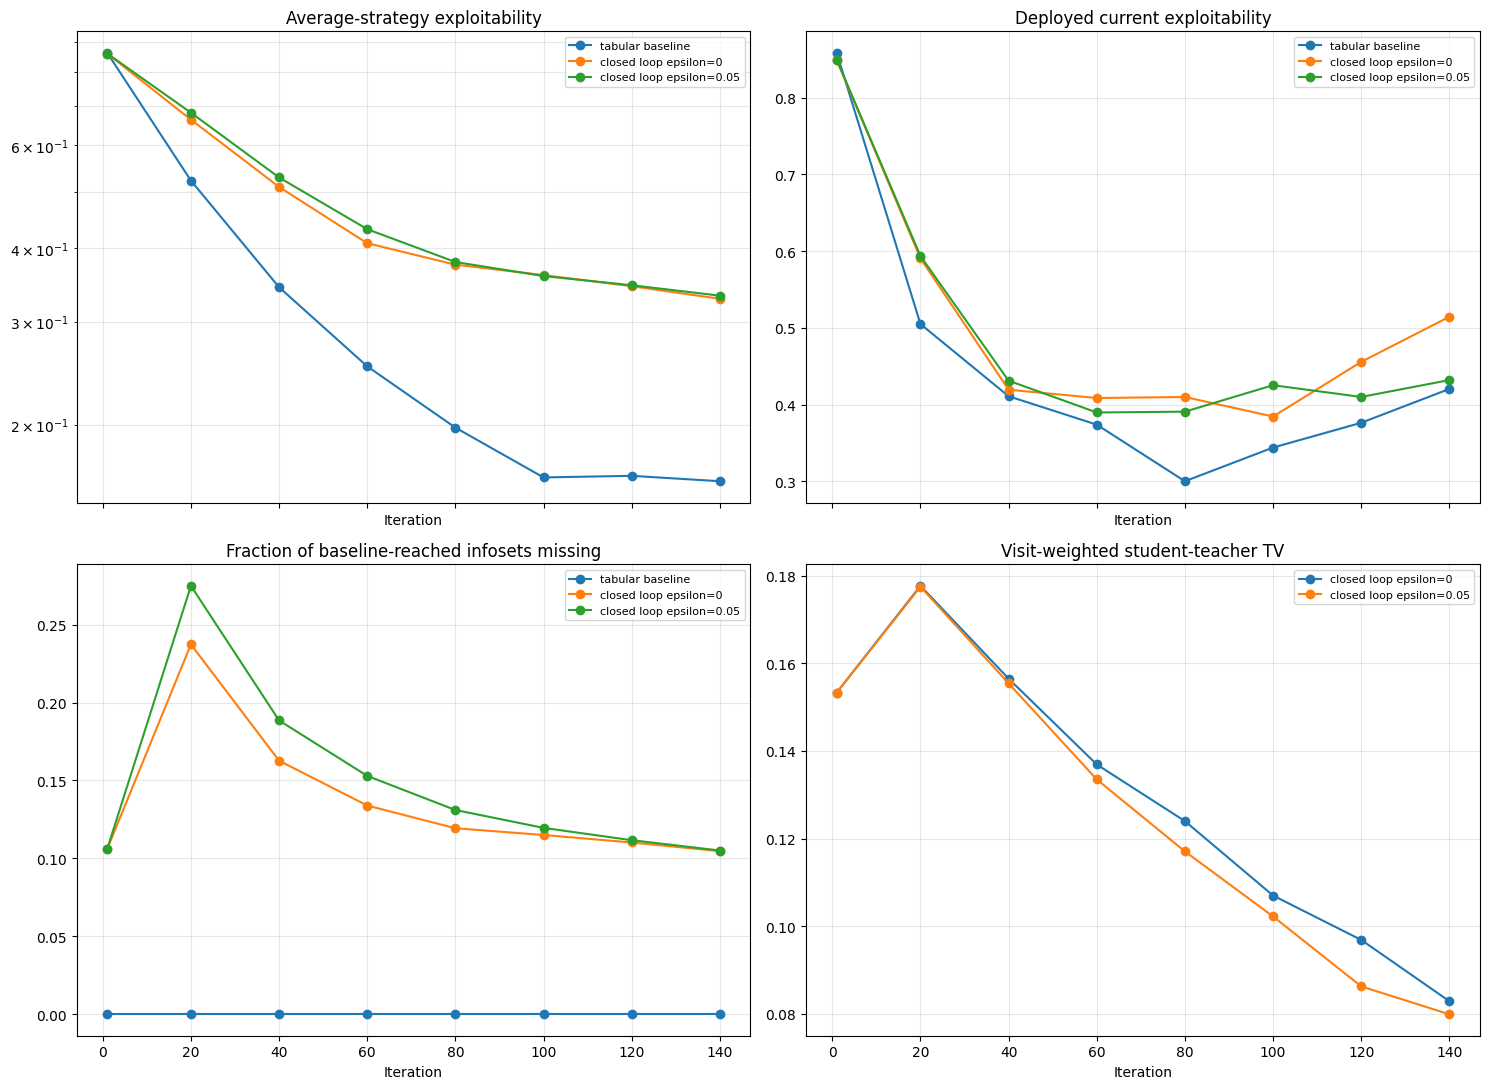

In [20]:
epsilon_variants = ['tabular baseline', 'closed loop epsilon=0', 'closed loop epsilon=0.05']

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
plot_specs = [
    ('average_exploitability', 'Average-strategy exploitability', True),
    ('deployed_current_exploitability', 'Deployed current exploitability', False),
    ('baseline_reached_missing', 'Fraction of baseline-reached infosets missing', False),
    ('visit_weighted_tv', 'Visit-weighted student-teacher TV', False),
]

for ax, (key, title, log_y) in zip(axes.flat, plot_specs):
    for label in epsilon_variants:
        subset = epsilon_df[epsilon_df['variant'] == label]
        grouped = subset.groupby('iter')[key]
        x = np.asarray(sorted(subset['iter'].unique()))
        mean = grouped.mean().reindex(x).to_numpy()
        low = grouped.min().reindex(x).to_numpy()
        high = grouped.max().reindex(x).to_numpy()
        if np.all(np.isnan(mean)):
            continue
        ax.plot(x, mean, marker='o', label=label)
        ax.fill_between(x, low, high, alpha=0.15)
    ax.set(title=title, xlabel='Iteration')
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [22]:
epsilon_seed_summary = []
for (variant, seed), group in epsilon_df.groupby(['variant', 'seed']):
    group = group.sort_values('iter')
    epsilon_seed_summary.append({
        'variant': variant,
        'seed': seed,
        'final average exploitability': group['average_exploitability'].iloc[-1],
        'best average exploitability': group['average_exploitability'].min(),
        'final deployed-current exploitability': group['deployed_current_exploitability'].iloc[-1],
        'final baseline-reached missing fraction': group['baseline_reached_missing'].iloc[-1],
        'final visit-weighted TV': group['visit_weighted_tv'].iloc[-1],
        'final unweighted TV': group['student_teacher_tv'].iloc[-1],
    })

epsilon_seed_summary = pd.DataFrame(epsilon_seed_summary)
epsilon_summary = epsilon_seed_summary.groupby('variant').agg(['mean', 'std'])
display(epsilon_summary.style.format(precision=6))
display(epsilon_final_df.groupby('variant').agg(['mean', 'std']).style.format(precision=6))


## Fixed-time advantage-loss ablation

This experiment changes only the advantage-network objective. Traversal, alternating updates, reservoir buffers, strategy-network training, architecture, optimizer, and evaluation remain fixed. Every variant receives the same measured training-time budget; exact best-response evaluations are excluded from that budget.

The four objectives are:

- **Masked MSE:** the existing Deep CFR objective.
- **Huber:** reduces the influence of unusually large sampled-regret errors.
- **Positive-weighted MSE:** gives positive sampled regrets three times the ordinary action weight.
- **MSE + sign auxiliary:** adds a small legal-action classification loss for whether sampled regret is positive.

These remain noisy instantaneous-regret targets, so success must be judged by average-policy exploitability rather than the reported training loss.

In [23]:
import torch.nn.functional as F

from liars_poker.algo.deep_cfr import DeepCFRTrainer


class AdvantageLossDeepCFRTrainer(DeepCFRTrainer):
    """Deep CFR with a selectable advantage loss and unchanged strategy loss."""

    def __init__(
        self,
        spec,
        *,
        advantage_loss='mse',
        positive_beta=2.0,
        sign_lambda=0.1,
        **kwargs,
    ):
        super().__init__(spec, **kwargs)
        self.advantage_loss = advantage_loss
        self.positive_beta = float(positive_beta)
        self.sign_lambda = float(sign_lambda)

    def _train_model(self, model, optimizer, buffer, steps, *, strategy_loss):
        if strategy_loss:
            return super()._train_model(
                model,
                optimizer,
                buffer,
                steps,
                strategy_loss=True,
            )
        if buffer.size == 0 or steps <= 0:
            return 0.0

        model.train()
        total_loss = 0.0
        for _ in range(steps):
            features, targets, masks, weights = buffer.sample(self.batch_size, self.rng)
            x = torch.from_numpy(features).to(self.device)
            y = torch.from_numpy(targets).to(self.device)
            mask = torch.from_numpy(masks).to(self.device)
            mask_float = mask.float()
            sample_weight = torch.from_numpy(weights).to(self.device)
            sample_weight = sample_weight / sample_weight.mean().clamp_min(1e-8)
            pred = model(x)

            if self.advantage_loss == 'mse':
                action_loss = (pred - y).square()
                per_sample = (action_loss * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp_min(1.0)
            elif self.advantage_loss == 'huber':
                action_loss = F.smooth_l1_loss(pred, y, reduction='none')
                per_sample = (action_loss * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp_min(1.0)
            elif self.advantage_loss == 'positive_weighted_mse':
                action_weight = mask_float * (1.0 + self.positive_beta * (y > 0.0).float())
                per_sample = ((pred - y).square() * action_weight).sum(dim=1) / action_weight.sum(dim=1).clamp_min(1.0)
            elif self.advantage_loss == 'mse_sign':
                squared = (pred - y).square()
                mse = (squared * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp_min(1.0)
                sign_bce = F.binary_cross_entropy_with_logits(pred, (y > 0.0).float(), reduction='none')
                sign_bce = (sign_bce * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp_min(1.0)
                per_sample = mse + self.sign_lambda * sign_bce
            else:
                raise ValueError(f'Unknown advantage loss: {self.advantage_loss}')

            loss = (per_sample * sample_weight).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())

        model.eval()
        return total_loss / steps

    def advantage_validation_details(self, *, max_records=4096):
        rows = []
        for pid in (0, 1):
            buffer = self.advantage_validation_buffers[pid]
            size = min(buffer.size, max_records)
            if size == 0:
                rows.append({'records': 0})
                continue
            x = torch.from_numpy(buffer.features[:size]).to(self.device)
            target = torch.from_numpy(buffer.targets[:size]).to(self.device)
            mask = torch.from_numpy(buffer.legal_masks[:size]).to(self.device)
            with torch.no_grad():
                pred = self.advantage_nets[pid](x)
                pred_strategy = self._regret_matching_tensor(pred, mask.float())
                target_strategy = self._regret_matching_tensor(target, mask.float())
            positive = mask & (target > 0.0)
            significant = mask & (target.abs() > 1e-3)
            rows.append({
                'records': size,
                'positive_sign_accuracy': float(((pred > 0.0) & positive).sum().item() / max(1, positive.sum().item())),
                'sign_accuracy': float((((pred > 0.0) == (target > 0.0)) & significant).sum().item() / max(1, significant.sum().item())),
                'top_action_match': float((pred_strategy.argmax(dim=1) == target_strategy.argmax(dim=1)).float().mean().cpu()),
                'strategy_tv': float((0.5 * torch.abs(pred_strategy - target_strategy).sum(dim=1)).mean().cpu()),
            })
        return rows


In [24]:
loss_training_seconds = 300
loss_eval_every = 10
loss_traversals_per_player = 50
loss_seed = 7

loss_common_kwargs = {
    'hidden_sizes': (64, 64),
    'advantage_buffer_capacity': 100_000,
    'strategy_buffer_capacity': 100_000,
    'batch_size': 128,
    'advantage_train_steps': 100,
    'strategy_train_steps': 100,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
    'highest_regret_fallback': True,
    'alternating_updates': True,
    'retrain_advantage_from_scratch': False,
    'validation_fraction': 0.05,
    'validation_buffer_capacity': 10_000,
    'seed': loss_seed,
}

loss_variants = {
    'masked MSE': {'advantage_loss': 'mse'},
    'Huber': {'advantage_loss': 'huber'},
    'positive-weighted MSE': {'advantage_loss': 'positive_weighted_mse', 'positive_beta': 2.0},
    'MSE + sign auxiliary': {'advantage_loss': 'mse_sign', 'sign_lambda': 0.1},
}

loss_runs = []
for label, loss_kwargs in loss_variants.items():
    print(f'\n=== {label} ===')
    trainer = AdvantageLossDeepCFRTrainer(spec, **loss_common_kwargs, **loss_kwargs)
    policy, logs, trainer = deep_cfr_timed_loop(
        spec,
        training_seconds=loss_training_seconds,
        trainer=trainer,
        traversals_per_player=loss_traversals_per_player,
        eval_every=loss_eval_every,
        debug=True,
    )
    loss_runs.append({
        'variant': label,
        'policy': policy,
        'logs': logs,
        'trainer': trainer,
        'advantage_validation_details': trainer.advantage_validation_details(),
    })



=== masked MSE ===
[deep-cfr] iter=1 training_budget=2.33/300.00s traverse=0.52s fit=1.82s
[deep-cfr] iter=2 training_budget=7.14/300.00s traverse=3.24s fit=1.57s
[deep-cfr] iter=3 training_budget=10.04/300.00s traverse=1.35s fit=1.56s
[deep-cfr] iter=4 training_budget=13.04/300.00s traverse=1.56s fit=1.44s
[deep-cfr] iter=5 training_budget=15.92/300.00s traverse=1.31s fit=1.57s
[deep-cfr] iter=6 training_budget=18.52/300.00s traverse=1.15s fit=1.45s
[deep-cfr] iter=7 training_budget=21.23/300.00s traverse=1.37s fit=1.35s
[deep-cfr] iter=8 training_budget=24.14/300.00s traverse=1.39s fit=1.51s
[deep-cfr] iter=9 training_budget=27.15/300.00s traverse=1.48s fit=1.53s
[deep-cfr] iter=10 training_budget=30.08/300.00s traverse=1.57s fit=1.36s
[deep-cfr] iter=11 training_budget=33.28/300.00s traverse=1.79s fit=1.40s
[deep-cfr] iter=12 training_budget=36.45/300.00s traverse=1.68s fit=1.50s
[deep-cfr] iter=13 training_budget=39.26/300.00s traverse=1.44s fit=1.37s
[deep-cfr] iter=14 training_b

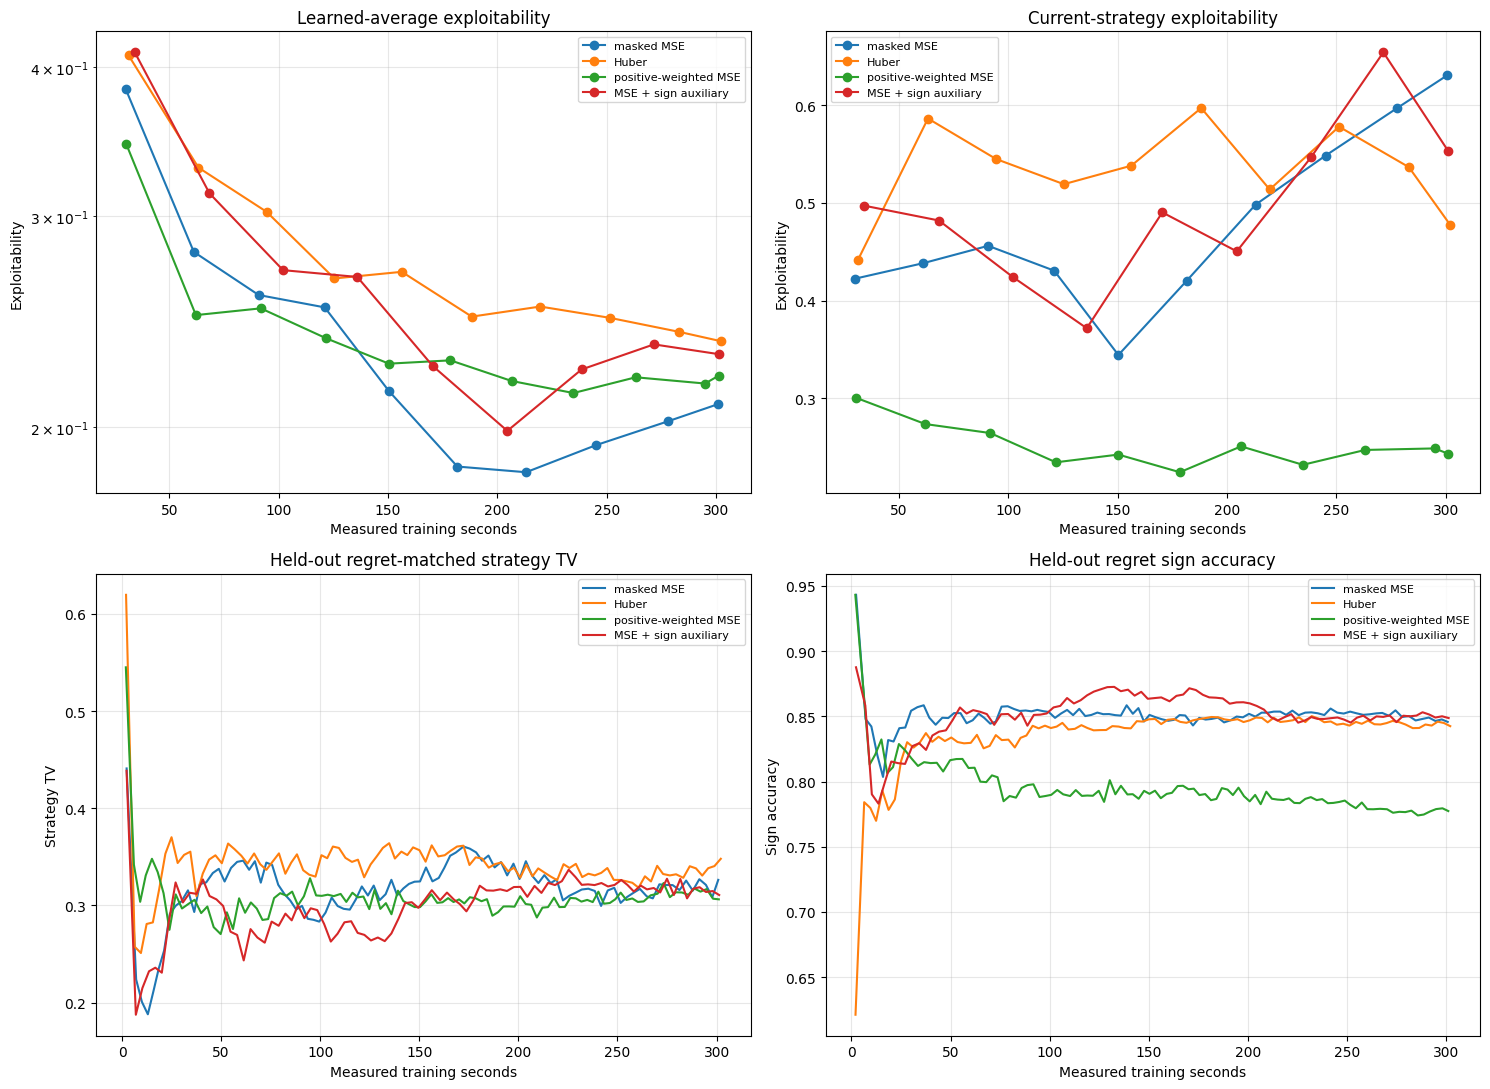

In [25]:
def loss_eval_seconds(run):
    elapsed_by_iter = {
        record['iteration']: record['elapsed_s']
        for record in run['logs']['training_series']
    }
    return np.asarray([elapsed_by_iter[point['iter']] for point in run['logs']['exploitability_series']])


def mean_loss_validation(run, family, key):
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    x = np.asarray([record['elapsed_s'] for record in records])
    y = np.asarray([
        np.mean([player[key] for player in record['validation'][family] if key in player])
        for record in records
    ])
    return x, y


fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for run in loss_runs:
    label = run['variant']
    series = run['logs']['exploitability_series']
    seconds = loss_eval_seconds(run)
    axes[0, 0].plot(seconds, [2 * point['predicted_avg'] - 1 for point in series], marker='o', label=label)
    axes[0, 1].plot(seconds, [2 * point['current_predicted_avg'] - 1 for point in series], marker='o', label=label)
    x, y = mean_loss_validation(run, 'advantage', 'strategy_tv')
    axes[1, 0].plot(x, y, label=label)
    x, y = mean_loss_validation(run, 'advantage', 'sign_accuracy')
    axes[1, 1].plot(x, y, label=label)

plot_specs = [
    ('Learned-average exploitability', 'Exploitability', True),
    ('Current-strategy exploitability', 'Exploitability', False),
    ('Held-out regret-matched strategy TV', 'Strategy TV', False),
    ('Held-out regret sign accuracy', 'Sign accuracy', False),
]
for ax, (title, ylabel, log_y) in zip(axes.flat, plot_specs):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [26]:
loss_summary = []
for run in loss_runs:
    training = run['logs']['training_series']
    series = run['logs']['exploitability_series']
    average = np.asarray([2 * point['predicted_avg'] - 1 for point in series])
    current = np.asarray([2 * point['current_predicted_avg'] - 1 for point in series])
    final_validation = run['advantage_validation_details']
    loss_summary.append({
        'variant': run['variant'],
        'iterations completed': run['trainer'].iteration,
        'final average exploitability': average[-1],
        'best average exploitability': average.min(),
        'final current exploitability': current[-1],
        'best current exploitability': current.min(),
        'final advantage loss': float(np.mean(training[-1]['advantage_loss'])),
        'final validation strategy TV': float(np.mean([row['strategy_tv'] for row in final_validation])),
        'final validation sign accuracy': float(np.mean([row['sign_accuracy'] for row in final_validation])),
        'final positive-sign recall': float(np.mean([row['positive_sign_accuracy'] for row in final_validation])),
        'final top-action match': float(np.mean([row['top_action_match'] for row in final_validation])),
        'mean traversal s': float(np.mean([record['timing']['traversal_s'] for record in training])),
        'mean advantage fit s': float(np.mean([record['timing']['advantage_training_s'] for record in training])),
        'mean strategy fit s': float(np.mean([record['timing']['strategy_training_s'] for record in training])),
    })

loss_summary_df = pd.DataFrame(loss_summary).set_index('variant')
loss_summary_df.style.format(precision=6).background_gradient(
    subset=['final average exploitability', 'best average exploitability'],
    cmap='RdYlGn_r',
)


,iterations completed,final average exploitability,best average exploitability,final current exploitability,best current exploitability,final advantage loss,final validation strategy TV,final validation sign accuracy,final positive-sign recall,final top-action match,mean traversal s,mean advantage fit s,mean strategy fit s
variant,,,,,,,,,,,,,
masked MSE,97,0.208951,0.183276,0.630741,0.344332,0.596909,0.326908,0.847400,0.445876,0.658740,1.619923,0.777327,0.704271
Huber,96,0.235909,0.235909,0.477451,0.441797,0.263354,0.347245,0.847495,0.377961,0.648379,1.649331,0.786540,0.711283
positive-weighted MSE,102,0.220728,0.213476,0.243326,0.224342,0.605740,0.316721,0.777019,0.850387,0.665808,1.439306,0.803017,0.710066
MSE + sign auxiliary,89,0.230061,0.198471,0.552692,0.371718,0.656611,0.309837,0.852176,0.370087,0.689607,1.795861,0.877748,0.711960


## Longer positive-weighting comparison with exact averaging

This narrows the previous loss ablation to masked MSE and gentler positive-regret weights. Every variant uses seed 17 and receives ten minutes of measured training time. The exact dense average of generated current strategies is tracked for every run, allowing us to separate:

- the quality of the generated strategy sequence (**exact average**),
- average-network distillation error (**learned average versus exact average**), and
- immediate current-policy quality.

Exact averaging, validation, and exact best-response evaluations remain outside the measured training budget, so total wall-clock time will exceed forty minutes.

In [28]:
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager

beta_training_seconds = 150
beta_eval_every = 10
beta_traversals_per_player = 50
beta_seed = 17

beta_common_kwargs = {
    **loss_common_kwargs,
    'seed': beta_seed,
}
beta_variants = {
    'masked MSE': {'advantage_loss': 'mse'},
    'positive beta=0.1': {'advantage_loss': 'positive_weighted_mse', 'positive_beta': 0.1},
    'positive beta=0.5': {'advantage_loss': 'positive_weighted_mse', 'positive_beta': 0.5},
    'positive beta=1.0': {'advantage_loss': 'positive_weighted_mse', 'positive_beta': 1.0},
}

beta_runs = []
for label, variant_kwargs in beta_variants.items():
    print(f'\n=== {label}; seed={beta_seed} ===')
    trainer = AdvantageLossDeepCFRTrainer(spec, **beta_common_kwargs, **variant_kwargs)
    exact_averager = ExactDenseStrategyAverager(spec)
    policy, logs, trainer = deep_cfr_timed_loop(
        spec,
        training_seconds=beta_training_seconds,
        trainer=trainer,
        traversals_per_player=beta_traversals_per_player,
        eval_every=beta_eval_every,
        exact_averager=exact_averager,
        debug=True,
    )
    beta_runs.append({
        'variant': label,
        'policy': policy,
        'logs': logs,
        'trainer': trainer,
        'exact_averager': exact_averager,
        'advantage_validation_details': trainer.advantage_validation_details(),
    })



=== masked MSE; seed=17 ===
[deep-cfr] iter=1 training_budget=1.62/150.00s traverse=0.40s fit=1.22s
[deep-cfr] iter=2 training_budget=4.95/150.00s traverse=2.07s fit=1.26s
[deep-cfr] iter=3 training_budget=7.18/150.00s traverse=1.03s fit=1.21s
[deep-cfr] iter=4 training_budget=9.63/150.00s traverse=1.20s fit=1.25s
[deep-cfr] iter=5 training_budget=12.04/150.00s traverse=1.15s fit=1.26s
[deep-cfr] iter=6 training_budget=14.40/150.00s traverse=1.14s fit=1.23s
[deep-cfr] iter=7 training_budget=16.77/150.00s traverse=1.20s fit=1.16s
[deep-cfr] iter=8 training_budget=19.20/150.00s traverse=1.18s fit=1.25s
[deep-cfr] iter=9 training_budget=21.84/150.00s traverse=1.30s fit=1.33s
[deep-cfr] iter=10 training_budget=24.26/150.00s traverse=1.19s fit=1.24s
[deep-cfr] iter=11 training_budget=26.61/150.00s traverse=1.12s fit=1.23s
[deep-cfr] iter=12 training_budget=28.92/150.00s traverse=1.13s fit=1.19s
[deep-cfr] iter=13 training_budget=31.31/150.00s traverse=1.20s fit=1.19s
[deep-cfr] iter=14 tra

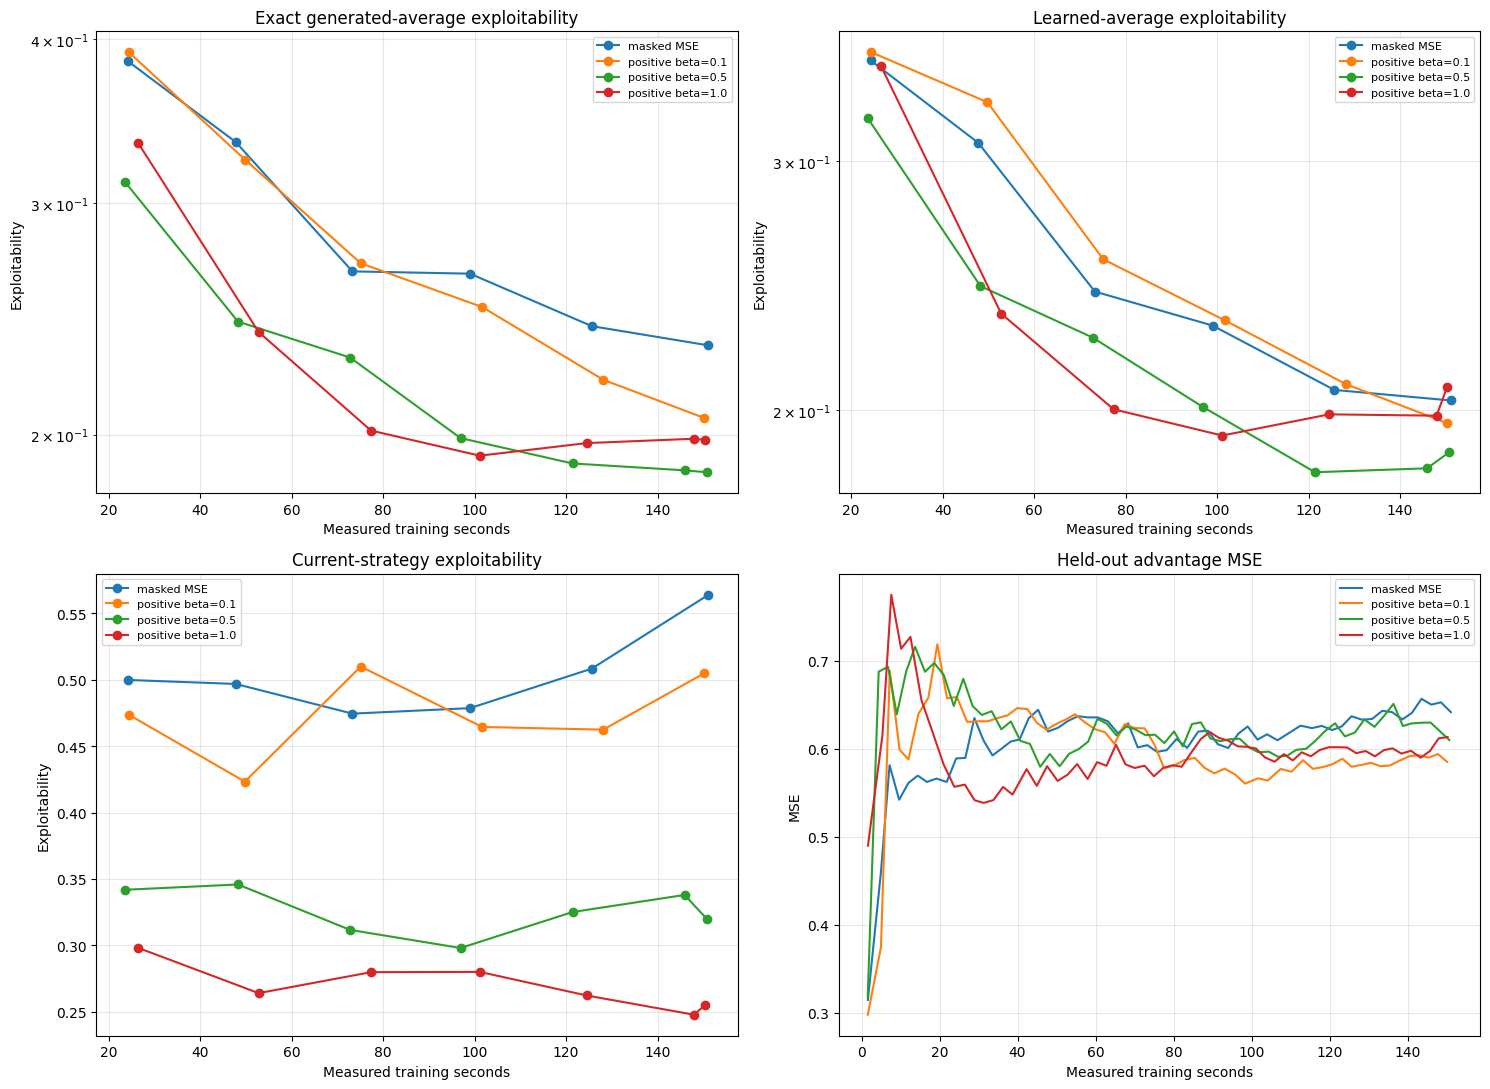

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for run in beta_runs:
    label = run['variant']
    series = run['logs']['exploitability_series']
    seconds = loss_eval_seconds(run)
    axes[0, 0].plot(seconds, [2 * point['exact_average_predicted_avg'] - 1 for point in series], marker='o', label=label)
    axes[0, 1].plot(seconds, [2 * point['predicted_avg'] - 1 for point in series], marker='o', label=label)
    axes[1, 0].plot(seconds, [2 * point['current_predicted_avg'] - 1 for point in series], marker='o', label=label)
    x, y = mean_loss_validation(run, 'advantage', 'mse')
    axes[1, 1].plot(x, y, label=label)

plot_specs = [
    ('Exact generated-average exploitability', 'Exploitability', True),
    ('Learned-average exploitability', 'Exploitability', True),
    ('Current-strategy exploitability', 'Exploitability', False),
    ('Held-out advantage MSE', 'MSE', False),
]
for ax, (title, ylabel, log_y) in zip(axes.flat, plot_specs):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [30]:
beta_summary = []
for run in beta_runs:
    training = run['logs']['training_series']
    series = run['logs']['exploitability_series']
    learned = np.asarray([2 * point['predicted_avg'] - 1 for point in series])
    exact = np.asarray([2 * point['exact_average_predicted_avg'] - 1 for point in series])
    current = np.asarray([2 * point['current_predicted_avg'] - 1 for point in series])
    final_validation = run['advantage_validation_details']
    validation_records = [record for record in training if 'validation' in record]
    final_validation_mse = np.mean([
        player['mse']
        for player in validation_records[-1]['validation']['advantage']
        if 'mse' in player
    ])
    beta_summary.append({
        'variant': run['variant'],
        'iterations completed': run['trainer'].iteration,
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'final learned-average exploitability': learned[-1],
        'best learned-average exploitability': learned.min(),
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'best current exploitability': current.min(),
        'final held-out advantage MSE': float(final_validation_mse),
        'final validation strategy TV': float(np.mean([row['strategy_tv'] for row in final_validation])),
        'final positive-sign recall': float(np.mean([row['positive_sign_accuracy'] for row in final_validation])),
        'final top-action match': float(np.mean([row['top_action_match'] for row in final_validation])),
        'mean traversal s': float(np.mean([record['timing']['traversal_s'] for record in training])),
        'mean advantage fit s': float(np.mean([record['timing']['advantage_training_s'] for record in training])),
        'mean strategy fit s': float(np.mean([record['timing']['strategy_training_s'] for record in training])),
    })

beta_summary_df = pd.DataFrame(beta_summary).set_index('variant')
beta_summary_df.style.format(precision=6).background_gradient(
    subset=[
        'final exact-average exploitability',
        'best exact-average exploitability',
        'final learned-average exploitability',
    ],
    cmap='RdYlGn_r',
)


,iterations completed,final exact-average exploitability,best exact-average exploitability,final learned-average exploitability,best learned-average exploitability,final learned-minus-exact gap,final current exploitability,best current exploitability,final held-out advantage MSE,final validation strategy TV,final positive-sign recall,final top-action match,mean traversal s,mean advantage fit s,mean strategy fit s
variant,,,,,,,,,,,,,,,
masked MSE,60,0.233860,0.233860,0.203160,0.203160,-0.030700,0.563740,0.474374,0.641520,0.305067,0.416001,0.683110,1.259091,0.621711,0.637549
positive beta=0.1,59,0.205899,0.205899,0.195835,0.195835,-0.010064,0.504671,0.423226,0.584936,0.306184,0.429453,0.688160,1.258419,0.644070,0.642739
positive beta=0.5,62,0.187191,0.187191,0.186709,0.180722,-0.000482,0.320096,0.298098,0.609803,0.307221,0.624694,0.666300,1.151343,0.643848,0.635923
positive beta=1.0,61,0.198071,0.192707,0.207598,0.191867,0.009527,0.254925,0.247910,0.613296,0.309237,0.760106,0.661748,1.154624,0.653100,0.655649
